# Imports

In [1]:
%load_ext autoreload
%autoreload 2

# Aquaplanet analysis config file
import config
import coords

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)

logger.info("Loading Imports...")
# File management
import glob
import os
import sys
from datetime import datetime, timedelta
import copy
import cftime

# Data anaylsis
import numpy as np
import scipy
import xarray as xr
import xeofs as xe
xr.set_options(keep_attrs=True)
import scipy.signal as signal
from scipy.stats import t

# Plotting
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from cartopy import util as cutil
# from plotting_utils import get_plotting_attributes
plt.rcParams['mathtext.fontset'] = 'dejavusans'
import string

# -------------------------------------------------------------------
# Cartopy (mapping + geospatial utilities)
# -------------------------------------------------------------------
from cartopy import crs as ccrs
from cartopy import feature as cf
from cartopy import util as cutil
from cartopy.mpl.ticker import (
    LongitudeFormatter,
    LatitudeFormatter,
    LongitudeLocator,
    LatitudeLocator,
)

# Auxiliary functions
# sys.path.insert(0, "/glade/u/home/sressel/thesis-work/python/auxiliary_functions/")
from load_aquaplanet_data import load_multi_experiment_processed_data
from auxiliary_functions import xarray_utils
from auxiliary_functions.plotting_utils import bmh_colors, tick_labeller, set_plot_mode, get_figsize
from auxiliary_functions.rounding_functions import round_out

logger.info("Imports loaded")

2026-07-23 15:44:05,805 [INFO] Loading Imports...
/glade/u/home/sressel/thesis-work/python/auxiliary_functions/src/auxiliary_functions/__init__.py:49: UserWarning: Could not import from calculate_velocity_potential (likely missing 'windspharm'): No module named 'windspharm'
  warnings.warn(f"Could not import from calculate_velocity_potential (likely missing 'windspharm'): {e}")
2026-07-23 15:44:06,090 [INFO] Imports loaded


# Load Data

## Budget variables

In [2]:
# data_directory = "/glade/derecho/scratch/sressel"
data_directory = r"/glade/campaign/univ/uwas0152/post_processed_data/"
# budget_to_load = 'MSE'
budget_to_load = 'moisture'
# budget_to_load = 'meridional_moisture_advection'
# data_source_to_load = '3-hourly_model-level'
# data_source_to_load = 'daily_pressure-level'
data_source_to_load = 'daily_model-level'

processes_to_load = 'single decomposed advection term'
# processes_to_load = 'full budget with decomposed advection terms'
# processes_to_load = 'full budget'

USE_ZONAL_MEAN_WIND = False

multi_experiment_budget_variables = {}
logger.info("Load Budget Variables")
budget_data_location = f"{data_directory}/{budget_to_load}_budget_terms/{data_source_to_load}_data"
if budget_to_load == 'MSE':
    budget_variables_to_load = [
        'Moist Static Energy',
        'Moist Static Energy Tendency',
        'Zonal Advection',
        'Meridional Advection',
        'Vertical Advection',
        'Latent Heating',
        'Sensible Heating',
        'Longwave Heating',
        'Shortwave Heating',
        'Residual'
    ]

elif budget_to_load == 'moisture':
    if processes_to_load == 'full budget':
        budget_variables_to_load = [
            'Moisture',
            'Moisture Tendency',
            'Zonal Advection',
            'Meridional Advection',
            'Vertical Advection',
            'Evaporation',
            'Precipitation',
            'Residual'
        ]

    elif processes_to_load == 'single decomposed advection term':
        advection_type = 'Meridional Advection'
        budget_variables_to_load = [
            'Precipitation',
            'Moisture',
            'Moisture Tendency',
            f'{advection_type}',
            f'{advection_type} Mean wind mean moisture',
            f'{advection_type} Mean wind MJO moisture',
            f'{advection_type} Mean wind residial moisture',
            f'{advection_type} MJO wind mean moisture',
            f'{advection_type} MJO wind MJO moisture',
            f'{advection_type} MJO wind residual moisture',
            f'{advection_type} Residual wind mean moisture',
            f'{advection_type} Residual wind MJO moisture',
            f'{advection_type} Residual wind residual moisture',
        ]

    elif processes_to_load == 'full budget with decomposed advection terms':
        budget_variables_to_load = [
            'Moisture',
            'Moisture Tendency',
            'Evaporation',
            'Precipitation',
            f'Zonal Advection Mean wind MJO moisture',
            f'Zonal Advection Residual wind residual moisture',
            f'Meridional Advection MJO wind mean moisture',
            f'Meridional Advection Residual wind residual moisture',
            f'Vertical Advection MJO wind mean moisture',
            'Residual'
        ]

for index, variable_name in enumerate(budget_variables_to_load):
    if variable_name == 'Meridional Advection Mean wind MJO moisture' and USE_ZONAL_MEAN_WIND:
        logger.info("        Using zonal mean meridional wind")
        data = xr.open_dataset(f"{budget_data_location}/multi_experiment_{variable_name.lower().replace(' ', '_')}_zonal_mean.nc")
    else:
        data = xr.open_dataset(f"{budget_data_location}/multi_experiment_{variable_name.lower().replace(' ', '_')}.nc")
    for variable_data in data.data_vars.values():
        logger.info(f"    {variable_name}...")
        multi_experiment_budget_variables[variable_name] = variable_data

logger.info("Finished")

2026-07-23 15:42:01,083 [INFO] Load Budget Variables
2026-07-23 15:42:01,180 [INFO]     Precipitation...
2026-07-23 15:42:01,232 [INFO]     Moisture...
2026-07-23 15:42:01,284 [INFO]     Moisture Tendency...
2026-07-23 15:42:01,339 [INFO]     Meridional Advection...
2026-07-23 15:42:01,497 [INFO]     Meridional Advection Mean wind mean moisture...
2026-07-23 15:42:01,559 [INFO]     Meridional Advection Mean wind MJO moisture...
2026-07-23 15:42:01,608 [INFO]     Meridional Advection Mean wind residial moisture...
2026-07-23 15:42:01,652 [INFO]     Meridional Advection MJO wind mean moisture...
2026-07-23 15:42:01,798 [INFO]     Meridional Advection MJO wind MJO moisture...
2026-07-23 15:42:01,849 [INFO]     Meridional Advection MJO wind residual moisture...
2026-07-23 15:42:01,905 [INFO]     Meridional Advection Residual wind mean moisture...
2026-07-23 15:42:01,961 [INFO]     Meridional Advection Residual wind MJO moisture...
2026-07-23 15:42:02,012 [INFO]     Meridional Advection Res

In [2]:
vertically_resolved_mean_wind_mjo_moisture = xr.open_dataset(
    "/glade/u/home/sressel/uwas0152-link/post_processed_data/moisture_budget_terms/daily_pressure-level_data/multi_experiment_meridional_advection_mean_wind_mjo_moisture.nc"
)['Meridional Advection Mean Wind MJO Moisture']

## Load/Define Reference Series

In [10]:
reference_variable = 'Precipitation'
# mjo_index_method = 'Huang24'
mjo_index_method = 'Modified AK12'

print(f"{f'Loading reference data':^{config.SEP_WIDTH}}")
print(f"Regression Method: {mjo_index_method}")
print(f"{'='*config.SEP_WIDTH}")

if mjo_index_method == 'Modified AK12':
    if not 'multi_experiment_variables_mjo_filtered' in locals():
        multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'mjo_filtered'
        )
    else:
        multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'mjo_filtered',
            multi_experiment_variables_mjo_filtered,
            False
        )

    time = multi_experiment_variables_mjo_filtered[reference_variable].time
    latitude = multi_experiment_variables_mjo_filtered[reference_variable].lat
    longitude = multi_experiment_variables_mjo_filtered[reference_variable].lon

    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Defining reference timeseries...':<{config.SEP_WIDTH-1}}", end="")
    reference_longitude = 180
    reference_latitude = 0

    reference_timeseries = multi_experiment_variables_mjo_filtered[reference_variable].sel(lat=reference_latitude, lon=reference_longitude, method='nearest')

    regression_info = {
        'regression_variable': f"MJO-filtered {reference_variable}",
        'mjo_index_method': 'Modified AK12',
        'reference_longitude': reference_longitude,
        'reference_latitude' : reference_latitude,
    }
    print(rf"{'✔':>1}")

elif mjo_index_method == 'AK12':
    if not 'multi_experiment_variables_mjo_filtered' in locals():
        multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'mjo_filtered'
        )
    else:
        multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'mjo_filtered',
            multi_experiment_variables_mjo_filtered,
            False
        )

    time = multi_experiment_variables_mjo_filtered[reference_variable].time
    latitude = multi_experiment_variables_mjo_filtered[reference_variable].lat
    longitude = multi_experiment_variables_mjo_filtered[reference_variable].lon

    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Defining reference timeseries...':<{config.SEP_WIDTH-1}}", end="")
    reference_longitude = 180
    reference_latitude = (
        multi_experiment_variables_mjo_filtered[reference_variable]
    ).var(dim='time').mean(dim='lon').idxmax(dim='lat')

    # Select the timeseries at the correct reference location for each experiment
    selected_timeseries = []
    for exp, lat in zip(multi_experiment_variables_mjo_filtered[reference_variable].experiment, reference_latitude):

        experiment_reference_timeseries = multi_experiment_variables_mjo_filtered[reference_variable].sel(
            experiment=exp, lat=lat, lon=reference_longitude
        )
        selected_timeseries.append(experiment_reference_timeseries)

    # Combine all timeseries into a single DataArray if needed
    reference_timeseries = xr.concat(selected_timeseries, dim="experiment")

    regression_info = {
        'regression_variable': f"MJO-filtered {reference_variable}",
        'mjo_index_method': 'AK12',
        'reference_longitude': reference_longitude,
        'reference_latitude_-4K': reference_latitude.sel(experiment='-4K').values,
        'reference_latitude_0K': reference_latitude.sel(experiment='0K').values,
        'reference_latitude_4K': reference_latitude.sel(experiment='4K').values
    }
    print(rf"{'✔':>1}")


elif mjo_index_method == 'Huang24':
    reference_region = dict(
        lat=slice(-5,5),
        lon=slice(175,185)
    )

    if not 'multi_experiment_variables_subset' in locals():
        multi_experiment_variables_subset = load_multi_experiment_processed_data(
            [reference_variable],
            'subset'
        )
    else:
        multi_experiment_variables_subset = load_multi_experiment_processed_data(
            [reference_variable],
            'subset',
            multi_experiment_variables_subset,
            False
        )
    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Defining reference timeseries...':<{config.SEP_WIDTH-1}}", end="")

    reference_region_data = multi_experiment_variables_subset[reference_variable].sel(reference_region).mean(dim=['lat', 'lon'])
    reference_timeseries = time_filter_data(
        reference_region_data,
        period_subset_bounds
    )
    regression_info = {
        'regression_variable': f"MJO-filtered {reference_variable}",
        'mjo_index_method': 'Huang24',
        'reference_longitude': f"{tick_labeller([reference_region['lon'].start], 'lon', False)[0]}-{tick_labeller([reference_region['lon'].stop], 'lon', False)[0]}",
        'reference_latitude': f"{tick_labeller([reference_region['lat'].start], 'lat', False)[0]}-{tick_labeller([reference_region['lat'].stop], 'lat', False)[0]}",
    }
    print(rf"{'✔':>1}")

elif mjo_index_method == 'Modified Huang24':
    reference_region = dict(
        lat=slice(-5,5),
        lon=slice(175,185)
    )

    if not 'multi_experiment_variables_mjo_filtered' in locals():
        multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'mjo_filtered'
        )
    else:
        multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'mjo_filtered',
            multi_experiment_variables_mjo_filtered,
            False
        )
    print(f"{'-'*config.SEP_WIDTH}")
    print(f"{f'Defining reference timeseries...':<{config.SEP_WIDTH-1}}", end="")

    reference_timeseries = multi_experiment_variables_mjo_filtered[reference_variable].sel(reference_region).mean(dim=['lat', 'lon'])
    regression_info = {
        'regression_variable': f"MJO-filtered {reference_variable}",
        'mjo_index_method': 'Modified Huang24',
        'reference_longitude': f"{tick_labeller([reference_region['lon'].start], 'lon', False)[0]}-{tick_labeller([reference_region['lon'].stop], 'lon', False)[0]}",
        'reference_latitude': f"{tick_labeller([reference_region['lat'].start], 'lat', False)[0]}-{tick_labeller([reference_region['lat'].stop], 'lat', False)[0]}",
    }
    print(rf"{'✔':>1}")

elif mjo_index_method == 'Rossby':
    reference_region = dict(
        lat=slice(-5,5),
        lon=slice(175,185)
    )

    if not 'multi_experiment_variables_rossby_filtered' in locals():
        multi_experiment_variables_rossby_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'rossby_filtered'
        )
    else:
        multi_experiment_variables_rossby_filtered = load_multi_experiment_processed_data(
            [reference_variable],
            'rossby_filtered',
            multi_experiment_variables_rossby_filtered,
            False
        )
    print(f"Defining reference timeseries")

    reference_timeseries = multi_experiment_variables_rossby_filtered[reference_variable].sel(reference_region).mean(dim=['lat', 'lon'])
    regression_info = {
        'regression_variable': f"MJO-filtered {reference_variable}",
        'mjo_index_method': 'Modified Huang24',
        'reference_longitude': f"{tick_labeller([reference_region['lon'].start], 'lon', False)[0]}-{tick_labeller([reference_region['lon'].stop], 'lon', False)[0]}",
        'reference_latitude': f"{tick_labeller([reference_region['lat'].start], 'lat', False)[0]}-{tick_labeller([reference_region['lat'].stop], 'lat', False)[0]}",
    }

logger.info("Finished")

2026-07-23 15:47:18,292 [INFO] Loading mjo_filtered data
2026-07-23 15:47:18,294 [INFO] (1/1) Precipitation...
2026-07-23 15:47:18,297 [INFO]     Experiment: -4K...


2026-07-23 15:47:18,352 [INFO]     Experiment: 0K...
2026-07-23 15:47:18,435 [INFO]     Experiment: 4K...


         Loading reference data         
Regression Method: Modified AK12


2026-07-23 15:47:19,203 [INFO] Finished
2026-07-23 15:47:19,207 [INFO] Finished


----------------------------------------
Defining reference timeseries...       ✔


# Process data

## Subset budget variables

In [5]:
logger.info(f"Subset budget variables")

multi_experiment_budget_variables_subset = {}

for index, (variable_name, variable_data) in enumerate(multi_experiment_budget_variables.items()):
    logger.info(f"  ({index+1}/{len(multi_experiment_budget_variables)}) {variable_name}...")

    multi_experiment_budget_variables_subset[variable_name] = variable_data.drop_sel(time=coords.missing_timesteps, errors='ignore')
# multi_experiment_budget_variables_subset[reference_variable] = variable_data.drop_sel(time=missing_timesteps, errors='ignore')

print("Finished")

2026-07-23 15:34:01,679 [INFO] Subset budget variables
2026-07-23 15:34:01,681 [INFO]   (1/13) Precipitation...
2026-07-23 15:34:01,689 [INFO]   (2/13) Moisture...
2026-07-23 15:34:01,696 [INFO]   (3/13) Moisture Tendency...
2026-07-23 15:34:01,715 [INFO]   (4/13) Meridional Advection...
2026-07-23 15:34:01,733 [INFO]   (5/13) Meridional Advection Mean wind mean moisture...
2026-07-23 15:34:01,743 [INFO]   (6/13) Meridional Advection Mean wind MJO moisture...


2026-07-23 15:34:01,762 [INFO]   (7/13) Meridional Advection Mean wind residial moisture...
2026-07-23 15:34:01,770 [INFO]   (8/13) Meridional Advection MJO wind mean moisture...
2026-07-23 15:34:01,776 [INFO]   (9/13) Meridional Advection MJO wind MJO moisture...
2026-07-23 15:34:01,784 [INFO]   (10/13) Meridional Advection MJO wind residual moisture...
2026-07-23 15:34:01,791 [INFO]   (11/13) Meridional Advection Residual wind mean moisture...
2026-07-23 15:34:01,797 [INFO]   (12/13) Meridional Advection Residual wind MJO moisture...
2026-07-23 15:34:01,804 [INFO]   (13/13) Meridional Advection Residual wind residual moisture...


Finished


## Regress variables

### Perform regression

In [12]:
recalculate_regressions = True

if not 'multi_experiment_variables_mjo_filtered' in locals():
    multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
        ['Precipitation'],
        'mjo_filtered'
    )
else:
    multi_experiment_variables_mjo_filtered = load_multi_experiment_processed_data(
        ['Precipitation'],
        'mjo_filtered',
        multi_experiment_variables_mjo_filtered,
        False
    )

time = multi_experiment_variables_mjo_filtered['Precipitation'].time
latitude = multi_experiment_variables_mjo_filtered['Precipitation'].lat
longitude = multi_experiment_variables_mjo_filtered['Precipitation'].lon

longitude_centers = np.arange(0, 360, 60)
longitude_coords = xr.DataArray(longitude_centers, dims="region", coords={'region':longitude_centers}, name="region_lon")
distance_to_center = xr.ufuncs.mod(longitude - longitude_coords, 360)
distance_to_center = xr.where(distance_to_center > 180, 360 - distance_to_center, distance_to_center)
lon_mask = distance_to_center <= 5
lat_mask = (latitude >= -5) & (latitude <= 5)
mask = lon_mask & lat_mask

masked = multi_experiment_variables_mjo_filtered['Precipitation'].where(mask)
mean_precipitation_by_region = masked.mean(dim=["lat", "lon"])

multi_experiment_variables_regressed_by_region = {}

underline = "\033[4m"
reset = "\033[0m"

save_regressed_variables = False
reference_variable = 'Precipitation'
data_type = 'regressed'

# Initialize the dictionary to hold the regressed values
standardized_reference_timeseries = mean_precipitation_by_region.stats.standardize(unit_variance=True, dim='time')

N = len(standardized_reference_timeseries.time)
t_critical = t.ppf(0.95, df=N-2)

# Average over regions
# Step 1: compute wrapped distance between each region center and every grid lon
distance_degrees = (longitude.values - longitude_coords.values[:, None] + 540) % 360 - 180

# Step 2: choose nearest lon index
region_center_idx = abs(distance_degrees).argmin(axis=1)

# Step 3: choose target index (I recommend mid-grid)
target_idx = list(longitude.lon.values).index(180)

# Step 4: compute shift amount
shift = target_idx - region_center_idx

logger.info(f"Regress Budget Variables onto {reference_variable}")

if 'multi_experiment_variables_regressed' not in locals() or recalculate_regressions:
    multi_experiment_variables_regressed = {}
    significant_regression_indices = {}

for index, (variable_name, variable_data) in enumerate(multi_experiment_budget_variables_subset.items()):

    logger.info(f"    ({index+1}/{len(multi_experiment_budget_variables_subset)}) {variable_name}...")
    if not recalculate_regressions and variable_name in multi_experiment_variables_regressed:
        logger.info(f"Using existing regression for {variable_name}")
        continue

    # Remove the time mean of the variables to be regressed
    # variable_data_anomalies = standardize_data(variable_data, unit_variance=False, dim='time')
    variable_data_anomalies = variable_data.stats.standardize(dim='time', unit_variance=False)

    if 'plev' not in variable_data.coords:
        variable_regressed_by_region = xr.dot(
            standardized_reference_timeseries,
            variable_data_anomalies,
            dim='time'
        ) / len(standardized_reference_timeseries.time)

        variable_regressed_with_shift = variable_regressed_by_region.assign_coords(shift_amount=("region", shift))
        # multi_experiment_variables_regressed[variable_name] = variable_regressed_with_shift.groupby("region").apply(
        #     lambda x: x.roll(lon=int(x.shift_amount), roll_coords=False)
        # ).mean(dim='region')
        multi_experiment_variables_regressed[variable_name] = variable_regressed_with_shift.groupby("region").apply(
            lambda x: x.roll(lon=int(x.shift_amount.item()), roll_coords=False)
        ).mean(dim='region')
        del variable_regressed_by_region, variable_regressed_with_shift

    else:
        multi_experiment_variables_regressed[variable_name] = xr.zeros_like(
            variable_data.isel(time=0, drop=True)
        ).transpose(..., 'plev')
        for (level_index, plev) in enumerate(variable_data.plev):
            if (plev % 250 == 0):
                print(f"{("\n" if plev == 250 else "")}{plev.values} hPa")

            variable_regressed_by_region_by_level = xr.dot(
                standardized_reference_timeseries,
                variable_data_anomalies.sel(plev=plev),
                dim='time'
            ) / len(standardized_reference_timeseries.time)

            variable_regressed_with_shift = variable_regressed_by_region_by_level.assign_coords(
                shift_amount=("region", shift)
            )
            multi_experiment_variables_regressed[variable_name][..., level_index] = variable_regressed_with_shift.groupby("region").apply(
                lambda x: x.roll(lon=int(x.shift_amount), roll_coords=False)
            ).mean(dim='region')
            del variable_regressed_by_region_by_level, variable_regressed_with_shift

    multi_experiment_variables_regressed[variable_name].attrs = variable_data_anomalies.attrs
    multi_experiment_variables_regressed[variable_name].name = variable_name

    # # Calculate the statstical significance of the regression coefficients
    # predicted_value = multi_experiment_variables_regressed[variable_name] * standardized_reference_timeseries
    # residual_sum_of_squares = ((variable_data_anomalies - predicted_value) ** 2).sum(dim='time')
    # residual_variance = residual_sum_of_squares / (N - 2)
    # standard_error_slope = np.sqrt(residual_variance / (N - 1))
    # t_statistic = multi_experiment_variables_regressed[variable_name] / standard_error_slope
    # significant_regression_indices[variable_name] = np.abs(t_statistic) > t_critical
    # print(rf"{'✔':>1}")

print("Finished")

2026-07-23 15:47:48,478 [INFO] Loading mjo_filtered data
2026-07-23 15:47:48,483 [INFO] (1/1) Precipitation...
2026-07-23 15:47:48,485 [INFO] Finished
2026-07-23 15:48:00,416 [INFO] Regress Budget Variables onto Precipitation


In [ ]:
vertically_resolved_mean_wind_mjo_moisture_subset = vertically_resolved_mean_wind_mjo_moisture.drop_sel(time=coords.missing_timesteps, 
errors='ignore')
vertically_resolved_mean_wind_mjo_moisture_anomalies = vertically_resolved_mean_wind_mjo_moisture_subset.stats.standardize(dim='time', unit_variance=False)

vertically_resolved_mean_wind_mjo_moisture_regressed = xr.zeros_like(
    vertically_resolved_mean_wind_mjo_moisture_anomalies.isel(time=0, drop=True)
).transpose(..., 'plev')
for (level_index, plev) in enumerate(vertically_resolved_mean_wind_mjo_moisture_regressed.plev):
    if (plev % 250 == 0):
        print(f"{("\n" if plev == 250 else "")}{plev.values} hPa")

    variable_regressed_by_region_by_level = xr.dot(
        standardized_reference_timeseries,
        vertically_resolved_mean_wind_mjo_moisture_anomalies['Meridional Advection Mean Wind MJO Moisture'].sel(plev=plev),
        dim='time'
    ) / len(standardized_reference_timeseries.time)

    variable_regressed_with_shift = variable_regressed_by_region_by_level.assign_coords(
        shift_amount=("region", shift)
    )
    vertically_resolved_mean_wind_mjo_moisture_regressed[..., level_index] = variable_regressed_with_shift.groupby("region").apply(
        lambda x: x.roll(lon=int(x.shift_amount.item()), roll_coords=False)
    ).mean(dim='region')
    del variable_regressed_by_region_by_level, variable_regressed_with_shift


250 hPa
500 hPa
750 hPa
1000 hPa


In [ ]:
latitudes = vertically_resolved_mean_wind_mjo_moisture.lat
longitudes = vertically_resolved_mean_wind_mjo_moisture.lon

latitude_bounds = xr.DataArray(
    [[3, 4, 4], [10, 8, 8]],
    dims=["bound", "experiment"],
    coords={"bound": ["lower", "upper"], "experiment": coords.experiments},
)

latitude_mask = (
    (latitudes >= latitude_bounds.sel(bound="lower"))
    & (latitudes <= latitude_bounds.sel(bound="upper"))
)

longitude_bounds = xr.DataArray(
    [[120, 120, 150], [180, 180, 210]],
    dims=["bound", "experiment"],
    coords={"bound": ["lower", "upper"], "experiment": coords.experiments},
)

longitude_mask = (
    (longitude >= longitude_bounds.sel(bound="lower"))
    & (longitude <= longitude_bounds.sel(bound="upper"))
)
vertically_resolved_mean_wind_mjo_moisture_subset = vertically_resolved_mean_wind_mjo_moisture.drop_sel(time=coords.missing_timesteps, 
errors='ignore').sel(plev=slice(100, 1000)).where(latitude_mask).where(longitude_mask)
# vertically_resolved_mean_wind_mjo_moisture_anomalies = vertically_resolved_mean_wind_mjo_moisture_subset.stats.standardize(dim='time', unit_variance=False)

In [ ]:
vertically_resolved_mean_wind_mjo_moisture_subset

In [6]:
std = vertically_resolved_mean_wind_mjo_moisture_subset.std(dim='time')

In [7]:
vertically_resolved_mean_wind_mjo_moisture_anomalies = (vertically_resolved_mean_wind_mjo_moisture_subset - mean)

In [8]:
vertically_resolved_mean_wind_mjo_moisture_anomalies

<xarray.DataArray 'Meridional Advection Mean Wind MJO Moisture' (experiment: 3,
                                                                 plev: 37,
                                                                 lat: 3,
                                                                 time: 3646,
                                                                 lon: 25)> Size: 243MB
array([[[[[-8.63663014e-16, -7.89790008e-16, -8.22717582e-16, ...,
           -3.18685034e-16, -5.18654010e-16, -8.02607175e-16],
          [-2.04995964e-15, -1.63703833e-15, -9.10232074e-16, ...,
            1.32228094e-15,  1.12105093e-15,  1.03250758e-15],
          [-3.14295922e-15, -2.42035469e-15, -9.77295782e-16, ...,
            2.87622330e-15,  2.68342526e-15,  2.79635824e-15],
          ...,
          [ 3.67206872e-15,  1.56522793e-15,  8.54078332e-17, ...,
           -5.74443469e-15, -5.78307219e-15, -5.36869387e-15],
          [ 2.48271872e-15,  9.37199737e-16, -1.21834414e-16, ...,
           -4.39933422e-15, -4.41563657e-15, -4.09699107e-15],
          [ 1.33570503e-15,  3.82399394e-16, -2.37235196e-16, ...,
           -3.00235008e-15, -2.98855900e-15, -2.76133609e-15]],

         [[-3.74257105e-16, -2.91947314e-16, -4.16770954e-16, ...,
           -1.22073102e-16, -2.14266684e-16, -3.29221713e-16],
          [-5.02219825e-16, -1.53173405e-16, -2.45728404e-16, ...,
            3.73342754e-16,  2.40034397e-16,  1.29456562e-16],
          [-6.26120463e-16, -2.37935476e-17, -7.96312135e-17, ...,
            8.51749907e-16,  6.83319625e-16,  5.79832477e-16],
...
            3.63277715e-09,  2.49164869e-09,  6.75257695e-10],
          [-1.65812712e-09, -3.16201451e-09, -3.85218063e-09, ...,
            2.74183122e-09,  1.81291922e-09,  4.69208813e-10],
          [-7.46885012e-10, -1.68835388e-09, -2.13417754e-09, ...,
            1.80519038e-09,  1.18971159e-09,  3.49617561e-10]],

         [[ 2.10145202e-10,  1.37915353e-10,  2.06402009e-10, ...,
           -8.91188887e-10, -8.50170100e-10, -9.54800960e-10],
          [ 5.39632236e-10,  6.13429005e-10,  7.75272812e-10, ...,
            1.15224604e-10, -2.25367899e-11, -5.01028178e-10],
          [ 8.92808957e-10,  1.10027181e-09,  1.32425056e-09, ...,
            1.14882802e-09,  8.16778391e-10,  2.50891125e-12],
          ...,
          [-1.83499080e-09, -1.63177417e-09, -3.11336371e-10, ...,
            7.92283286e-10, -1.42540462e-09, -1.64616422e-09],
          [-9.98252066e-10, -8.59562005e-10,  7.37421620e-11, ...,
            5.73369379e-10, -1.11691051e-09, -1.23491873e-09],
          [-1.33772652e-10, -6.94598757e-11,  4.14386029e-10, ...,
            5.00918852e-10, -6.10205200e-10, -6.83549667e-10]]]]],
      shape=(3, 37, 3, 3646, 25))
Coordinates:
  * lat         (lat) float64 24B 2.842 4.737 6.632
  * lon         (lon) float64 200B 150.0 152.5 155.0 157.5 ... 205.0 207.5 210.0
  * time        (time) object 29kB 0003-01-04 00:00:00 ... 0013-01-03 00:00:00
  * plev        (plev) int64 296B 100 125 150 175 200 ... 900 925 950 975 1000
  * experiment  (experiment) <U3 36B '-4K' '0K' '4K'

In [14]:
# vertically_resolved_mean_wind_mjo_moisture_subset = vertically_resolved_mean_wind_mjo_moisture.drop_sel(time=coords.missing_timesteps, 
# errors='ignore')
# vertically_resolved_mean_wind_mjo_moisture_anomalies = vertically_resolved_mean_wind_mjo_moisture_subset.stats.standardize(dim='time', unit_variance=False)

vertically_resolved_mean_wind_mjo_moisture_regressed = xr.zeros_like(
    vertically_resolved_mean_wind_mjo_moisture_anomalies.isel(time=0, drop=True)
).transpose(..., 'plev')
for (level_index, plev) in enumerate(vertically_resolved_mean_wind_mjo_moisture_regressed.plev):
    if (plev % 250 == 0):
        print(f"{("\n" if plev == 250 else "")}{plev.values} hPa")

    variable_regressed_by_region_by_level = xr.dot(
        standardized_reference_timeseries,
        vertically_resolved_mean_wind_mjo_moisture_anomalies.sel(plev=plev),
        dim='time'
    ) / len(standardized_reference_timeseries.time)

    variable_regressed_with_shift = variable_regressed_by_region_by_level.assign_coords(
        shift_amount=("region", shift)
    )
    vertically_resolved_mean_wind_mjo_moisture_regressed[..., level_index] = variable_regressed_with_shift.groupby("region").apply(
        lambda x: x.roll(lon=int(x.shift_amount.item()), roll_coords=False)
    ).mean(dim='region')
    del variable_regressed_by_region_by_level, variable_regressed_with_shift


250 hPa
500 hPa
750 hPa
1000 hPa


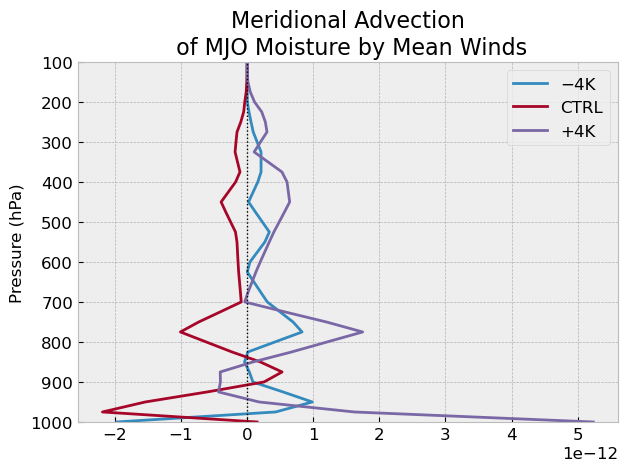

In [26]:
SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'onecol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '12'
plt.rcParams['axes.labelsize'] = '12'
plt.rcParams['xtick.labelsize'] = '12'
plt.rcParams['ytick.labelsize'] = '12'
plt.rcParams['lines.linewidth'] = '2'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(1, 1, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.25)

ax = fig.add_subplot(gs[0])
for index, experiment in enumerate(coords.experiments.values):
    ax.plot(
        vertically_resolved_mean_wind_mjo_moisture_regressed.mean(dim=['lat', 'lon']).sel(experiment=experiment),
        vertically_resolved_mean_wind_mjo_moisture_regressed.plev,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )

ax.axvline(x=0, ls=':', color='k', lw=1)
ax.set_ylim(100, 1000)
ax.set_yticks(np.arange(100, 1100, 100))
ax.invert_yaxis()
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Meridional Advection\n of MJO Moisture by Mean Winds')
ax.legend(loc='upper right')
plt.show()

# Budget contributions

## Calculate budget contributions

In [ ]:
logger.info(f"Calculate Budget Contributions")

# projection_variable = 'Moist Static Energy'
projection_variable = 'Moisture'
budget_maintenance_contribution = {}
budget_propagation_contribution = {}

multi_experiment_budget_variables_regressed = multi_experiment_variables_regressed

for index, (budget_term, budget_data) in enumerate(multi_experiment_budget_variables_regressed.items()):
    logger.info(f"  ({index+1}/{len(multi_experiment_budget_variables_regressed)}) {budget_term}...")

    # Maintenance
    maintenance_numerator = (
        multi_experiment_budget_variables_regressed[projection_variable]
        * budget_data
    )
    maintenance_denominator = (
        multi_experiment_budget_variables_regressed[projection_variable]**2
    )
    budget_maintenance_contribution[budget_term] = (
        maintenance_numerator.sel(lat=slice(-15,15)).integrate('lat').integrate('lon') 
        / maintenance_denominator.sel(lat=slice(-15,15)).integrate('lat').integrate('lon')
    )
    budget_maintenance_contribution[budget_term].attrs = budget_data.attrs

    # Propagation
    propagation_numerator = (
        multi_experiment_budget_variables_regressed[f"{projection_variable} Tendency"]
        * budget_data
    )
    propagation_denominator = (
        multi_experiment_budget_variables_regressed[f"{projection_variable} Tendency"]**2
    )

    budget_propagation_contribution[budget_term] = (
        propagation_numerator.sel(lat=slice(-15,15)).integrate('lat').integrate('lon') 
        / propagation_denominator.sel(lat=slice(-15,15)).integrate('lat').integrate('lon')
    )
    budget_propagation_contribution[budget_term].attrs = budget_data.attrs

logger.info("Finished")

## Plot Budgets

### Full Budget

#### Plotting Parameters

In [ ]:
calculate_horizontal_advection = True
if projection_variable == 'Moist Static Energy':
    if mjo_index_method == 'Huang24' or mjo_index_method == 'Modified Huang24' or mjo_index_method == 'Rossby' or mjo_index_method == 'Modified AK12':
        # Huang (2024) term order
        budget_term_attributes = {
            'Moist Static Energy Tendency': {
                'label': r"$\langle \partial_{t} h \rangle$",
                'color': plt.get_cmap('Blues'),
            },
            'Longwave Heating': {
                'label': r"$\langle$LW$\rangle$",
                'color': mcolors.LinearSegmentedColormap.from_list("Pinks", ["#ffd6e6", "#ffb3cc", "#ff80b3", "#ff3385", "#e60073"], N=256),
            },
            'Shortwave Heating': {
                'label': r"$\langle$SW$\rangle$",
                'color': mcolors.LinearSegmentedColormap.from_list("Golden",["#fff9cc", "#ffe999", "#ffcc66",  "#e6b347", "#c49e35"], N=256),
            },
            'Latent Heating': {
                'label': r'LH',
                'color': plt.get_cmap('Greens'),
            },
            'Sensible Heating': {
                'label': r'SH',
                'color': mcolors.LinearSegmentedColormap.from_list("Cyans", ["#e0ffff", "#80e0ff", "#00c0ff", "#0080ff", "#0040ff"], N=256),
            },
            'Horizontal Advection': {
                'label': r"-$\langle \vec{v}\cdot \nabla h \rangle$",
                'color': plt.get_cmap('Oranges'),
            },
            'Vertical Advection': {
                'label': r"-$\langle \omega \partial_{p} h \rangle$",
                'color': plt.get_cmap('Purples'),
            },
            'Residual': {
                'label': r"Res.",
                'color': plt.get_cmap('Greys'),
            },
            'Radiative Heating': {
                'label': r"$\langle Q_R \rangle$",
                'color': mcolors.LinearSegmentedColormap.from_list("Pinks", ["#ffd6e6", "#ffb3cc", "#ff80b3", "#ff3385", "#e60073"], N=256),
            },
            'Column Process': {
                'label': r"-$\langle \omega \partial_{p} h \rangle + \langle Q_R \rangle$",
                'color': plt.get_cmap('Purples'),
            },
        }
    elif mjo_index_method == 'AK12':
        # Anderson & Kuang term order
        budget_term_attributes = {
            'Moist Static Energy Tendency': {
                'label': r"$\langle \partial_{t} h \rangle$",
                'color': plt.get_cmap('Blues'),
            },
            'Longwave Heating': {
                'label': r"$\langle$LW$\rangle$",
                'color': mcolors.LinearSegmentedColormap.from_list("Pinks", ["#ffd6e6", "#ffb3cc", "#ff80b3", "#ff3385", "#e60073"], N=256),
            },
            'Column Process': {
            'label': r'-$\langle \omega \partial_{p} m \rangle$+$\langle$LW$\rangle$',
            'color': plt.get_cmap('Purples'),
            },
            'Horizontal Advection': {
                'label': r"-$\langle \vec{v}\cdot \nabla h \rangle$",
                'color': plt.get_cmap('Oranges'),
            },
            'Zonal Advection': {
                'label': r"-$\langle u \partial_{x} h \rangle$",
                'color': plt.get_cmap('Oranges'),
            },
            'Meridional Advection': {
            'label': r"-$\langle v \partial_{y} h \rangle$",
            'color': plt.get_cmap('Oranges'),
            },
            'Vertical Advection': {
                'label': r"-$\langle \omega \partial_{p} h \rangle$",
                'color': plt.get_cmap('Purples'),
            },
            'Latent Heating': {
                'label': r'LH',
                'color': plt.get_cmap('Greens'),
            },
            'Sensible Heating': {
                'label': r'SH',
                'color': mcolors.LinearSegmentedColormap.from_list("Cyans", ["#e0ffff", "#80e0ff", "#00c0ff", "#0080ff", "#0040ff"], N=256),
            },
            'Shortwave Heating': {
                'label': r"$\langle$SW$\rangle$",
                'color': mcolors.LinearSegmentedColormap.from_list("Golden",["#fff9cc", "#ffe999", "#ffcc66",  "#e6b347", "#c49e35"], N=256),
            },
            'Residual': {
                'label': r"Res.",
                'color': plt.get_cmap('Greys'),
            },
        }

elif projection_variable == 'Moisture':
    # Huang (2024) term order
    budget_term_attributes = {
        'Moisture Tendency': {
            # 'label': r"$\langle \partial_{t} q \rangle$",
            'label': 'Moisture \nTendency',
            'color': plt.get_cmap('Blues'),
        },
        'Evaporation': {
            # 'label': r'E',
            'label': r'Evaporation',
            'color': plt.get_cmap('Greens'),
        },
        'Precipitation': {
            # 'label': r'-P',
            'label': r'Precipitation',
            'color': mcolors.LinearSegmentedColormap.from_list("Cyans", ["#e0ffff", "#80e0ff", "#00c0ff", "#0080ff", "#0040ff"], N=256),
        },
        'Precipitation + Vertical Advection': {
            # 'label': r"-(P + $\langle \omega \partial_{p} q \rangle$)",
            'label': "Column \nProcess \n (-P + vAdv)",
            'color': plt.get_cmap('Purples'),
        },
        'Precipitation + Vertical Advection + Residual': {
            # 'label': r"-(P + $\langle \omega \partial_{p} q \rangle$) + Res.",
            'label': r"-P - $\langle \omega \partial_{p} q \rangle$ + Res.",
            'color': plt.get_cmap('Purples'),
        },
        'Precipitation + Vertical Advection + Residual + Evaporation': {
            # 'label': r"-(P + $\langle \omega \partial_{p} q \rangle$) + Res.",
            'label': r"-P - $\langle \omega \partial_{p} q \rangle$ + Res. + E",
            'color': plt.get_cmap('Purples'),
        },
        'Precipitation + Residual + Evaporation': {
            # 'label': r"-(P + $\langle \omega \partial_{p} q \rangle$) + Res.",
            'label': r"-P + Res. + E",
            'color': plt.get_cmap('Purples'),
        },
        'Column Process': {
            # 'label': r'-$\langle \omega \partial_{p} q \rangle$-P + Res.',
            'label': r'Col. Process',
            'color': plt.get_cmap('Purples'),
        },
        'Horizontal Advection': {
            'label': r"-$\langle \vec{v}\cdot \nabla q \rangle$",
            'color': plt.get_cmap('Oranges'),
        },
        'Zonal Advection': {
            # 'label': r'-$\langle u \partial_{x} q \rangle$',
            'label': 'Zonal \nAdvection',
            'color': mcolors.LinearSegmentedColormap.from_list("HighContrastPinks", ["#fff0f5", "#ffb3cc", "#ff80b3", "#ff3385", "#cc005f"], N=256)
        },
        'Meridional Advection': {
            # 'label': r'-$\langle v \partial_{y} q \rangle$',
            'label': 'Meridional \nAdvection',
            'color': mcolors.LinearSegmentedColormap.from_list("Golden",["#fff9cc", "#ffe999", "#ffcc66",  "#e6b347", "#c49e35"], N=256),
        },
        'Vertical Advection': {
            'label': r"-$\langle \omega \partial_{p} q \rangle$",
            'color': plt.get_cmap('Purples'),
        },
        'Residual': {
            # 'label': r"Res.",
            'label': r"Residual",
            'color': plt.get_cmap('Greys'),
        },
    }

    print(f"{f'Column Process...':<{config.SEP_WIDTH-1}}", end="")
    budget_maintenance_contribution['Column Process'] = (
        budget_maintenance_contribution['Vertical Advection']
        + budget_maintenance_contribution['Evaporation']
        + budget_maintenance_contribution['Precipitation']
        + budget_maintenance_contribution['Residual']
    )
    budget_propagation_contribution['Column Process'] = (
        budget_propagation_contribution['Vertical Advection']
        + budget_propagation_contribution['Evaporation']
        + budget_propagation_contribution['Precipitation']
        + budget_propagation_contribution['Residual']
    )

    budget_maintenance_contribution['Precipitation + Vertical Advection'] = (
        budget_maintenance_contribution['Vertical Advection']
        + budget_maintenance_contribution['Precipitation']
    )
    budget_propagation_contribution['Precipitation + Vertical Advection'] = (
        budget_propagation_contribution['Vertical Advection']
        + budget_propagation_contribution['Precipitation']
    )
    budget_maintenance_contribution['Precipitation + Vertical Advection + Residual'] = (
        budget_maintenance_contribution['Vertical Advection']
        + budget_maintenance_contribution['Precipitation']
        + budget_maintenance_contribution['Residual']
    )
    budget_propagation_contribution['Precipitation + Vertical Advection + Residual'] = (
        budget_propagation_contribution['Vertical Advection']
        + budget_propagation_contribution['Precipitation']
        + budget_propagation_contribution['Residual']
    )
    budget_maintenance_contribution['Precipitation + Residual + Evaporation'] = (
        + budget_maintenance_contribution['Precipitation']
        + budget_maintenance_contribution['Residual']
        + budget_maintenance_contribution['Evaporation']
    )
    budget_propagation_contribution['Precipitation + Residual + Evaporation'] = (
        + budget_propagation_contribution['Precipitation']
        + budget_propagation_contribution['Residual']
        + budget_propagation_contribution['Evaporation']
    )
    budget_maintenance_contribution['Precipitation + Vertical Advection + Residual + Evaporation'] = (
        budget_maintenance_contribution['Vertical Advection']
        + budget_maintenance_contribution['Precipitation']
        + budget_maintenance_contribution['Residual']
        + budget_maintenance_contribution['Evaporation']
    )
    budget_propagation_contribution['Precipitation + Vertical Advection + Residual + Evaporation'] = (
        budget_propagation_contribution['Vertical Advection']
        + budget_propagation_contribution['Precipitation']
        + budget_propagation_contribution['Residual']
        + budget_propagation_contribution['Evaporation']
    )
    print(rf"{'✔':>1}")

if calculate_horizontal_advection:
    print(f"{f'Horizontal Advection...':<{config.SEP_WIDTH-1}}", end="")
    budget_maintenance_contribution['Horizontal Advection'] = (
        budget_maintenance_contribution['Zonal Advection']
        + budget_maintenance_contribution['Meridional Advection']
    )
    budget_propagation_contribution['Horizontal Advection'] = (
        budget_propagation_contribution['Zonal Advection']
        + budget_propagation_contribution['Meridional Advection']
    )

    print(rf"{'✔':>1}")

# budget_maintenance_contribution['Radiative Heating'] = (
#     budget_maintenance_contribution['Longwave Heating']
#     + budget_maintenance_contribution['Shortwave Heating']
# )
# budget_propagation_contribution['Radiative Heating'] = (
#     budget_propagation_contribution['Longwave Heating']
#     + budget_propagation_contribution['Shortwave Heating']
# )

# budget_maintenance_contribution['Column Process'] = (
#     budget_maintenance_contribution['Radiative Heating']
#     + budget_maintenance_contribution['Vertical Advection']
# )
# budget_propagation_contribution['Column Process'] = (
#     budget_propagation_contribution['Radiative Heating']
#     + budget_propagation_contribution['Vertical Advection']
# )

#### Maintenance

In [ ]:
savefig = False
# projected_variable = "Moist Static Energy"

# processes_to_plot = [
#     'Moisture Tendency',
#     'Evaporation',
#     # 'Precipitation',
#     'Precipitation + Vertical Advection',
#     # 'Precipitation + Residual + Evaporation',
#     # 'Vertical Advection',
#     'Zonal Advection',
#     'Meridional Advection',
#     # 'Vertical Advection',
#     # 'Precipitation',
#     # 'Column Process',
#     'Residual',
# ]

processes_to_plot = [
    'Moisture Tendency',
    'Zonal Advection',
    'Meridional Advection',
    'Precipitation + Vertical Advection',
    'Evaporation',
    # 'Precipitation',
    # 'Precipitation + Residual + Evaporation',
    # 'Vertical Advection',
    # 'Vertical Advection',
    # 'Precipitation',
    # 'Column Process',
    'Residual',
]

# plt.style.use('bmh')
# fontsize=8
# plt.rcParams.update({'font.size': fontsize, 'mathtext.fontset': 'dejavusans'})

# fig, ax = plt.subplots(1, 1, figsize=(5.5, 2.0))

SAVE_FIG = True
PLOT_MODE = "publication"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot()

bar_width = 0.25
# bar_width = 0.225
x_positions = np.arange(len(processes_to_plot))

# Plot bars for each experiment
for i, experiment in enumerate(coords.experiments.values):
    ax.bar(
        x_positions + i * bar_width,
        # x_positions - 3*bar_width/2 + i*bar_width + bar_width/2,
        [config.SECONDS_PER_DAY*budget_maintenance_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=1,
        zorder=10
    )

ax.set_ylabel(r'day$^{-1}$')
ax.set_xticks(x_positions + bar_width, labels=[budget_term_attributes[process]['label'] for process in processes_to_plot])
ax.set_yticks(np.arange(-0.1, 0.15, 0.05))
ax.axhline(y=0, color='#bcbcbc')
ax.grid(axis='x')
ax.set_ylim(-0.1125, 0.1375)
ax.set_xlim(ax.get_xticks()[0]-0.5, ax.get_xticks()[-1]+0.5)

[ax.axvline(x=(position + bar_width+0.5), ls=':', color='#bcbcbc', lw=1.5) for position in x_positions[:-1]]

for spine in ax.spines.values():
    spine.set_edgecolor("#bcbcbc")
    spine.set_linewidth(1.5)

# Add legend to distinguish experiments
ax.legend()
# fig.autofmt_xdate(ha='center', rotation=0)

# Save figure
output_filename = f"{projection_variable.replace(" ", "_").title()} Budget Maintenance"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis/{output_filename}.pdf",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

#### Propagation

In [ ]:
# projected_variable = "Moist Static Energy"

processes_to_plot = [
    'Moisture Tendency',
    'Evaporation',
    'Precipitation + Vertical Advection',
    'Zonal Advection',
    'Meridional Advection',
    # 'Vertical Advection',
    # 'Column Process',
    'Residual',
]

plt.style.use('bmh')
plt.rcParams.update({'font.size': 16, 'mathtext.fontset': 'dejavusans'})

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
# ax.set_title(
#     (
#         f"{projection_variable} Budget Propagation Contributions "
#     + f"\n Ressel Code, {budget_propagation_contribution[projection_variable].attrs['Regression Method']} Regression Method"
#     ),
#     pad=15
# )

bar_width = 0.25
x_positions = np.arange(len(processes_to_plot))

# Plot bars for each experiment
for i, experiment in enumerate(experiments_list):
    ax.bar(
        x_positions + i * bar_width,
        [budget_propagation_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=2,
    )

# ax.set_ylabel(r'day$^{-1}$')
ax.set_xticks(x_positions + bar_width, labels=[budget_term_attributes[process]['label'] for process in processes_to_plot], fontsize=18)
ax.axhline(y=0, color='#bcbcbc', lw=3)
ax.grid(axis='x')

for spine in ax.spines.values():
    spine.set_edgecolor("#bcbcbc")
    spine.set_linewidth(3)

# Add legend to distinguish experiments
ax.legend(fontsize=14)

plt.show()

#### Combined Maintenance-Propagation

In [ ]:
# projected_variable = "Moist Static Energy"
savefig = True

processes_to_plot = [
    'Moisture Tendency',
    'Evaporation',
    # 'Precipitation + Vertical Advection + Residual',
    'Precipitation + Vertical Advection',
    # 'Precipitation',
    # 'Vertical Advection',
    'Zonal Advection',
    'Meridional Advection',
    # 'Precipitation',
    # 'Column Process',
    'Residual',
]

# processes_to_plot = [
#     'Moist Static Energy Tendency',
#     # 'Longwave Heating',
#     # 'Shortwave Heating',
#     'Latent Heating',
#     'Sensible Heating',
#     'Horizontal Advection',
#     'Column Process',
#     # 'Vertical Advection',
#     'Residual',
# ]

plt.style.use('bmh')
plt.rcParams.update({'font.size': 16, 'mathtext.fontset': 'dejavusans'})

# fig = plt.figure(figsize=(16, 12))
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 1, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.25)

ax = []
ax.append(fig.add_subplot(gs[0]))
ax.append(fig.add_subplot(gs[1]))
# fig, ax = plt.subplots(2, 1, figsize=(16, 9))
# ax.set_title(
#     (
#         f"{projection_variable} Budget Maintenance Contributions "
#     + f"\n Ressel Code, {budget_maintenance_contribution[projection_variable].attrs['Regression Method']} Regression Method"
#     ),
#     pad=15
# )

bar_width = 0.25
x_positions = np.arange(len(processes_to_plot))

ax[0].set_title('a) Maintenance', pad=10, loc='left')
ax[1].set_title('b) Propagation', pad=10, loc='left')

# Plot bars for each experiment
for i, experiment in enumerate(experiments_list):
    plot_label = (
        f"{experiments_array.sel(experiment=experiment)['name'].item()}"
        # + f" ({tick_labeller(latitude_integration_bounds[experiment], 'lat', precision=0)[0]}"
        # + f"-{tick_labeller(latitude_integration_bounds[experiment], 'lat', precision=0)[1]}), All Lon"
        # + f" ({tick_labeller(longitude_integration_bounds[experiment], 'lon', precision=0)[0]}"
        # + f"-{tick_labeller(longitude_integration_bounds[experiment], 'lon', precision=0)[1]})"
    )
    ax[0].bar(
        x_positions + i * bar_width,
        [SECONDS_PER_DAY*budget_maintenance_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=plot_label,
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=2,
    )

    ax[1].bar(
        x_positions + i * bar_width,
        [budget_propagation_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=plot_label,
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=2,
    )

ax[0].set_ylabel(r'day$^{-1}$')
# ax[0].set_ylim(-0.15, 0.15)
# Add legend to distinguish experiments
ax[0].legend(fontsize=16)

# ax[1].set_ylim(-0.25, 1.25)
# ax[1].set_yticks(np.arange(-0.25, 1.5, 0.25))

for ax in ax:
    ax.set_xticks(x_positions + bar_width, labels=[budget_term_attributes[process]['label'] for process in processes_to_plot], fontsize=18)
    ax.axhline(y=0, color='#bcbcbc', lw=3)
    ax.grid(axis='x')
    [ax.axvline(x=(position + 3*bar_width), ls=':', color='#bcbcbc') for position in x_positions[:-1]]

    for spine in ax.spines.values():
        spine.set_edgecolor("#bcbcbc")
        spine.set_linewidth(3)

# fig.autofmt_xdate()

# Save figure
output_filename = f"{projection_variable.lower().replace(" ", "_")}_budget_maintenance_propagation"
print(f"Output directory: {aquaplanet_output_directory}/budget_analysis")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

### Advection Term Budget 

#### Plotting Parameters

In [ ]:
advection_type_colormap = {}
advection_type_colormap['Zonal Advection'] =\
    mcolors.LinearSegmentedColormap.from_list("HighContrastPinks", ["#fff0f5", "#ffb3cc", "#ff80b3", "#ff3385", "#cc005f"], N=256)
advection_type_colormap['Meridional Advection'] =\
    mcolors.LinearSegmentedColormap.from_list("Golden",["#fff9cc", "#ffe999", "#ffcc66",  "#e6b347", "#c49e35"], N=256)
advection_type_colormap['Vertical Advection'] = plt.get_cmap('Purples')

wind_variable = {}
wind_variable['Zonal Advection'] = 'u'
wind_variable['Meridional Advection'] = 'v'
wind_variable['Vertical Advection'] = r"\omega"

gradient_axis = {}
gradient_axis['Zonal Advection'] = 'x'
gradient_axis['Meridional Advection'] = 'y'
gradient_axis['Vertical Advection'] = "p"

if processes_to_load == 'single decomposed advection term':
    budget_maintenance_contribution[f'{advection_type} Sum'] = (
        budget_maintenance_contribution[f'{advection_type} Mean wind mean moisture']
        + budget_maintenance_contribution[f'{advection_type} Mean wind MJO moisture']
        + budget_maintenance_contribution[f'{advection_type} Mean wind residial moisture']
        + budget_maintenance_contribution[f'{advection_type} MJO wind mean moisture']
        + budget_maintenance_contribution[f'{advection_type} MJO wind MJO moisture']
        + budget_maintenance_contribution[f'{advection_type} MJO wind residual moisture']
        + budget_maintenance_contribution[f'{advection_type} Residual wind mean moisture']
        + budget_maintenance_contribution[f'{advection_type} Residual wind MJO moisture']
        + budget_maintenance_contribution[f'{advection_type} Residual wind residual moisture']
    )

    budget_propagation_contribution[f'{advection_type} Sum'] = (
        budget_propagation_contribution[f'{advection_type} Mean wind mean moisture']
        + budget_propagation_contribution[f'{advection_type} Mean wind MJO moisture']
        + budget_propagation_contribution[f'{advection_type} Mean wind residial moisture']
        + budget_propagation_contribution[f'{advection_type} MJO wind mean moisture']
        + budget_propagation_contribution[f'{advection_type} MJO wind MJO moisture']
        + budget_propagation_contribution[f'{advection_type} MJO wind residual moisture']
        + budget_propagation_contribution[f'{advection_type} Residual wind mean moisture']
        + budget_propagation_contribution[f'{advection_type} Residual wind MJO moisture']
        + budget_propagation_contribution[f'{advection_type} Residual wind residual moisture']
    )

    budget_term_attributes = {
    f'{advection_type}': {
        # 'label': budget_maintenance_contribution[f'{advection_type}'].attrs['math_name'],
        'label': fr"$-\langle {wind_variable[advection_type]} \cdot \partial_{{{gradient_axis[advection_type]}}} q \rangle$",
        # 'label': f"Vertical Moisture Advection",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Sum': {
        'label': 'Sum',
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Mean wind mean moisture': {
        'label': fr"$-\langle \bar{{{wind_variable[advection_type]}}} \cdot \partial_{{{gradient_axis[advection_type]}}} \bar{{q}} \rangle$",
        # 'label': f"Mean Wind-Mean Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Mean wind MJO moisture': {
        'label': fr"$-\langle \bar{{{wind_variable[advection_type]}}} \cdot \partial_{{{gradient_axis[advection_type]}}} q_\text{{MJO}} \rangle$",
        # 'label': f"Mean Wind-MJO Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Mean wind residial moisture': {
        'label': fr"$-\langle \bar{{{wind_variable[advection_type]}}} \cdot \partial_{{{gradient_axis[advection_type]}}} q_{{r}} \rangle$",
        # 'label': f"Mean Wind-Residual Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} MJO wind mean moisture': {
        'label': fr"$-\langle {wind_variable[advection_type]}_\text{{MJO}} \cdot \partial_{{{gradient_axis[advection_type]}}} \bar{{q}} \rangle$",
        # 'label': f"MJO Wind-Mean Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} MJO wind MJO moisture': {
        'label': fr"$-\langle {wind_variable[advection_type]}_\text{{MJO}} \cdot \partial_{{{gradient_axis[advection_type]}}} q_\text{{MJO}} \rangle$",
        # 'label': f"MJO Wind-MJO Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} MJO wind residual moisture': {
        'label': fr"$-\langle {wind_variable[advection_type]}_\text{{MJO}} \cdot \partial_{{{gradient_axis[advection_type]}}} q_{{r}} \rangle$",
        # 'label': f"MJO Wind-Residual Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Residual wind mean moisture': {
        'label': fr"$-\langle {wind_variable[advection_type]}_{{r}} \cdot \partial_{{{gradient_axis[advection_type]}}} \bar{{q}} \rangle$",
        # 'label': f"Residual Wind-Mean Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Residual wind MJO moisture': {
        'label': fr"$-\langle {wind_variable[advection_type]}_{{r}} \cdot \partial_{{{gradient_axis[advection_type]}}} q_\text{{MJO}} \rangle$",
        # 'label': f"Residual Wind-MJO Moisture",
        'color': advection_type_colormap[advection_type],
    },
    f'{advection_type} Residual wind residual moisture': {
        'label': fr"$-\langle {wind_variable[advection_type]}_{{r}} \cdot \partial_{{{gradient_axis[advection_type]}}} q_{{r}} \rangle$",
        # 'label': f"Residual Wind-Residual Moisture",
        'color': advection_type_colormap[advection_type],
    },
    # f'Precipitation': {
    #     'label': budget_maintenance_contribution[Precipitation].attrs['math_name'],
    #     'color': advection_type_colormap[advection_type],
    # },
}



elif processes_to_load == 'full budget with decomposed advection terms':
    budget_maintenance_contribution['Precipitation + Vertical Advection'] = (
        budget_maintenance_contribution[f'Precipitation']
        + budget_maintenance_contribution[f'Vertical Advection MJO wind mean moisture']
    )

    budget_propagation_contribution[f'Precipitation + Vertical Advection'] = (
        budget_propagation_contribution[f'Precipitation']
        + budget_propagation_contribution[f'Vertical Advection MJO wind mean moisture']
    )

    budget_term_attributes = {
        'Moisture Tendency': {
            'label': r"$\langle \partial_{t} q \rangle$",
            'color': plt.get_cmap('Blues'),
        },
        'Evaporation': {
            'label': r'E',
            'color': plt.get_cmap('Greens'),
        },
        'Precipitation': {
            'label': r'-P',
            'color': mcolors.LinearSegmentedColormap.from_list("Cyans", ["#e0ffff", "#80e0ff", "#00c0ff", "#0080ff", "#0040ff"], N=256),
        },
        f'Vertical Advection MJO wind mean moisture': {
            # 'label': budget_maintenance_contribution[f'{advection_type}'].attrs['math_name'],
            'label': r"$-\langle \omega_\text{MJO} \cdot \partial_p \bar{q} \rangle$",
            'color': advection_type_colormap['Vertical Advection'],
        },
        f'Precipitation + Vertical Advection': {
            'label': r"$-(P + \langle \omega_\text{MJO} \cdot \partial_p \bar{q} \rangle$)",
            'color': advection_type_colormap['Vertical Advection'],
        },
        f'Zonal Advection Mean wind MJO moisture': {
            # 'label': budget_maintenance_contribution[f'{advection_type}'].attrs['math_name'],
            'label': r"$-\langle \bar{u} \cdot \partial_x q_\text{MJO} \rangle$",
            'color': advection_type_colormap['Zonal Advection'],
        },
        f'Zonal Advection Residual wind residual moisture': {
            # 'label': budget_maintenance_contribution[f'{advection_type}'].attrs['math_name'],
            'label': r"$-\langle u_r \cdot \partial_x q_r \rangle$",
            'color': advection_type_colormap['Zonal Advection'],
        },
        f'Meridional Advection MJO wind mean moisture': {
            # 'label': budget_maintenance_contribution[f'{advection_type}'].attrs['math_name'],
            'label': r"$-\langle v_\text{MJO} \cdot \partial_y \bar{q} \rangle$",
            'color': advection_type_colormap['Meridional Advection'],
        },
        f'Meridional Advection Residual wind residual moisture': {
            # 'label': budget_maintenance_contribution[f'{advection_type}'].attrs['math_name'],
            'label': r"$-\langle v_r \cdot \partial_y q_r \rangle$",
            'color': advection_type_colormap['Meridional Advection'],
        },
        'Residual': {
            'label': r"Res.",
            'color': plt.get_cmap('Greys'),
        },
}

#### Combined Maintenance and Propagation

In [ ]:
savefig = False

if processes_to_load == 'single decomposed advection term':
    processes_to_plot = [
        f'{advection_type}',
        # 'Precipitation',
        # f'{advection_type} Mean wind mean moisture',
        f'{advection_type} Mean wind MJO moisture',
        # f'{advection_type} Mean wind residial moisture',
        f'{advection_type} MJO wind mean moisture',
        f'{advection_type} MJO wind MJO moisture',
        f'{advection_type} MJO wind residual moisture',
        # f'{advection_type} Residual wind mean moisture',
        f'{advection_type} Residual wind MJO moisture',
        f'{advection_type} Residual wind residual moisture',
        # f'{advection_type} Sum',
    ]

elif processes_to_load == 'full budget with decomposed advection terms':
    processes_to_plot = [
        'Moisture Tendency',
        'Evaporation',
        # 'Precipitation',
        # f'Vertical Advection MJO wind mean moisture',
        'Precipitation + Vertical Advection',
        f'Zonal Advection Mean wind MJO moisture',
        f'Zonal Advection Residual wind residual moisture',
        f'Meridional Advection MJO wind mean moisture',
        f'Meridional Advection Residual wind residual moisture',
        'Residual'
    ]

plt.style.use('bmh')
plt.rcParams.update({'font.size': 14, 'mathtext.fontset': 'dejavusans'})

fig, ax = plt.subplots(2, 1, figsize=(16, 9))

bar_width = 0.25
x_positions = np.arange(len(processes_to_plot))

# Plot bars for each experiment
ax[0].set_title("a) Maintenance", pad=10, loc='left')
ax[1].set_title("b) Propagation", pad=10, loc='left')
for i, experiment in enumerate(coords.experiments.values):
    ax[0].bar(
        x_positions + i * bar_width,
        [config.SECONDS_PER_DAY*budget_maintenance_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=2,
    )

    ax[1].bar(
        x_positions + i * bar_width,
        [budget_propagation_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=2,
    )

ax[0].set_ylabel(r'day$^{-1}$')

# Zonal
# ax[0].set_ylim(-0.05, 0.05)
# ax[0].set_yticks(np.arange(-0.05, 0.075, 0.025))

# Meridional
# ax[0].set_ylim(-0.075, 0.15)
# ax[0].set_yticks(np.arange(-0.075, 0.125+0.05, 0.05))
# ax[1].set_ylim(-0.25, 1.5)
# ax[1].set_yticks(np.arange(-0.25, 1.25+0.5, 0.5))

# Vertical
# ax[0].set_ylim(-0.1, 1.1)
# ax[0].set_yticks(np.arange(-0.1, 1.1+0.1, 0.2))
# ax[1].set_ylim(-3.5, 0.5)
# ax[1].set_yticks(np.arange(-3.5, 0.5+0.75, 0.75))

ax[0].set_xticks(x_positions + bar_width, labels=[])

ax[1].set_xticks(x_positions + bar_width, labels=[budget_term_attributes[process]['label'] for process in processes_to_plot], fontsize=16)#, rotation=-25, ha='left')

# Add legend to distinguish experiments
ax[0].legend(fontsize=14)

for ax in ax:
    ax.set_xlim(x_positions[0] - 0.25, x_positions[-1] + 3*bar_width)
    [ax.axvline(x=(position + 3*bar_width), ls=':', color='#bcbcbc') for position in x_positions]
    ax.axvline(x=(x_positions[0] + 3*bar_width), ls=(0, (10, 3)), color='#bcbcbc', lw=3)
    # ax.axvline(x=(x_positions[-3] + 3*bar_width), ls=(0, (10, 3)), color='#bcbcbc', lw=3)
    # [ax.axvline(x=(position + 3*bar_width), ls=':', color='#bcbcbc') for position in x_positions[-1:]]
    ax.axhline(y=0, color='#bcbcbc', lw=2)
    ax.grid(axis='x')

    for spine in ax.spines.values():
        spine.set_edgecolor("#bcbcbc")
        spine.set_linewidth(3)

fig.autofmt_xdate()

# Save figure
# output_filename = f"{projection_variable.lower().replace(" ", "_")}_budget_maintenance_propagation_{advection_type.lower().replace(" ", "_")}_decomposed"
output_filename = "Decomposed Zonal Advection Term"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

#### Maintenance

In [ ]:
savefig = False

if processes_to_load == 'single decomposed advection term':
    processes_to_plot = [
        f'{advection_type}',
        # 'Precipitation',
        # f'{advection_type} Mean wind mean moisture',
        f'{advection_type} Mean wind MJO moisture',
        # f'{advection_type} Mean wind residial moisture',
        f'{advection_type} MJO wind mean moisture',
        f'{advection_type} MJO wind MJO moisture',
        f'{advection_type} MJO wind residual moisture',
        # f'{advection_type} Residual wind mean moisture',
        f'{advection_type} Residual wind MJO moisture',
        f'{advection_type} Residual wind residual moisture',
        # f'{advection_type} Sum',
    ]

elif processes_to_load == 'full budget with decomposed advection terms':
    processes_to_plot = [
        'Moisture Tendency',
        'Evaporation',
        # 'Precipitation',
        # f'Vertical Advection MJO wind mean moisture',
        'Precipitation + Vertical Advection',
        f'Zonal Advection Mean wind MJO moisture',
        f'Zonal Advection Residual wind residual moisture',
        f'Meridional Advection MJO wind mean moisture',
        f'Meridional Advection Residual wind residual moisture',
        'Residual'
    ]


SAVE_FIG = False
PLOT_MODE = "publication"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = fig.add_gridspec(1, 1)

ax = fig.add_subplot(gs[0])

bar_width = 0.25
x_positions = np.arange(len(processes_to_plot))

# Plot bars for each experiment
for i, experiment in enumerate(coords.experiments.values):

    ax.bar(
        x_positions + i * bar_width,
        [config.SECONDS_PER_DAY*budget_maintenance_contribution[process].sel(experiment=experiment).values for process in processes_to_plot],
        width=bar_width,
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in processes_to_plot],
        edgecolor='#bcbcbc',
        lw=1,
    )

ax.set_ylabel(r'day$^{-1}$')
ax.set_xticks(x_positions + bar_width, labels=[budget_term_attributes[process]['label'] for process in processes_to_plot])

ax.set_ylim(-0.0625, 0.05)
ax.axhline(y=0, color='#bcbcbc', lw=1)
ax.grid(axis='x')

ax.set_xlim(x_positions[0] - 0.25, x_positions[-1] + 3*bar_width)

[ax.axvline(x=(position + 3*bar_width), ls=':', color='#bcbcbc') for position in x_positions[1:]]
ax.axvline(x=(x_positions[0] + 3*bar_width), ls=(0, (10, 2)), color='#bcbcbc', lw=2)

for spine in ax.spines.values():
    spine.set_edgecolor("#bcbcbc")
    spine.set_linewidth(2)

# Add legend to distinguish experiments
ax.legend()

fig.autofmt_xdate()


# Save figure
output_filename = "Decomposed Meridional Advection Term - Subset"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [ ]:
[fig, ax] = plt.subplots(1, 1, figsize=(12,6))


bar_width = 0.25
x_positions = np.arange(len(['', '']))


for i, experiment in enumerate(coords.experiments.values):
    ax.bar(
        x_positions + i * bar_width,
        width=bar_width,
        height=config.SECONDS_PER_DAY*zonal_mean_values.sel(experiment=experiment),
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in ['Meridional Advection Mean wind MJO moisture']],
        edgecolor='#bcbcbc',
        lw=1,
    )
    ax.bar(
        x_positions + i * bar_width,
        width=bar_width,
        height=config.SECONDS_PER_DAY*original_values.sel(experiment=experiment),
        color=[budget_term_attributes[process]['color'](0.3 + 0.35 * i) for process in ['Meridional Advection Mean wind MJO moisture']],
        edgecolor='#bcbcbc',
        lw=1,
    )
plt.show()

In [ ]:
x = np.arange(len(coords.experiments.values))
width = 0.4
plt.style.use('default')
fig, ax = plt.subplots(figsize=(7, 4))

bars1 = ax.bar(x - width/2, config.SECONDS_PER_DAY*original_values.values, width, label='Original')
bars2 = ax.bar(x + width/2, config.SECONDS_PER_DAY*zonal_mean_values.values, width, label='Zonal Mean')

ax.set_xticks(x)
ax.set_xticklabels([config.EXPERIMENT_DISPLAY_NAMES[exp] for exp in coords.experiments.values])
ax.set_xlabel('Experiment')
ax.set_ylabel('Value')
ax.set_title('Original vs Zonal Mean Values by Experiment')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Optional: label bars with their values
ax.bar_label(bars1, fmt='%.5f', padding=3)
ax.bar_label(bars2, fmt='%.5f', padding=3)
ax.set_ylim(-0.0135, 0.008)

plt.tight_layout()
plt.show()

In [ ]:
projection_variable = 'Moisture'
merged_multi_experiment_budget_variables_regressed = xr.merge(
    [
        multi_experiment_budget_variables_regressed['Moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} Mean wind mean moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} Mean wind MJO moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} Mean wind residial moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} MJO wind mean moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} MJO wind MJO moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} MJO wind residual moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} Residual wind mean moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} Residual wind MJO moisture'],
        multi_experiment_budget_variables_regressed[f'{advection_type} Residual wind residual moisture'],
    ]
)

latitude_bounds = (-20, 20)

experiment_to_plot = '4K'
savefig=False

plt.style.use('default')
plt.rcParams.update({'font.size':20})

colormap = 'RdYlBu_r'

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(5, 5, width_ratios=[15,15,15,15,2], figure=fig)
# gs = GridSpec(3, 5, width_ratios=[15,15,15,15,2], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.25)

axes = []
axes.append(fig.add_subplot(gs[0, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[3, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[3, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[4, 1:3], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_ax = fig.add_subplot(gs[:,-1])

grand_max = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().max(),
    order=6
)
grand_min = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().min(),
    order=6
)
# levels = np.arange(grand_min, grand_max+2.5, 2.5)
levels = np.linspace(grand_min, grand_max, 21)

fig.suptitle(
    f"{config.EXPERIMENT_DISPLAY_NAMES[experiment]} MJO {projection_variable.title()} Budget Terms,\n {mjo_index_method} Regression Method",
    x=0.5,
    y=1.075
)

for ax, (variable_name, variable_data) in zip(
    axes,
    list(
        merged_multi_experiment_budget_variables_regressed.drop_vars(projection_variable).data_vars.items()
    )
):
    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=slice(*latitude_bounds)).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    ax.set_title(f"{variable_data.attrs['math_name']}", pad=10)
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=slice(*latitude_bounds)),
        cdata,
        # cmap=colormap,
        cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # levels=np.linspace(grand_min, grand_max, 21),
        levels=levels,
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        merged_multi_experiment_budget_variables_regressed[projection_variable].sel(experiment=experiment_to_plot),
        merged_multi_experiment_budget_variables_regressed[projection_variable].lon
    )

    ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=7
    )

    if mjo_index_method == 'AK12':
        ax.plot(
            reference_longitude,
            reference_latitude.sel(experiment=experiment_to_plot),
            transform=ccrs.PlateCarree(),
            marker='x',
            color='black',
            ms=10
        )


for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labeller(x_ticks+180, "lon", precision=0))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    if index == len(axes)-1:
        ax.set_xlabel("Longitude")

    ax.set_ylim(*latitude_bounds)
    y_ticks = np.arange(latitude_bounds[0], latitude_bounds[1]+10, 10)
    ax.set_yticks(y_ticks)
    if index%2 == 0:
        ax.set_yticklabels(tick_labeller(y_ticks, "lat", precision=0))
        ax.set_ylabel("Latitude")
    else:
        ax.set_yticklabels('')

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

cbar = fig.colorbar(im, cax=cbar_ax, format='%.2e')
# cbar.set_label(r"W m$^{-2}$")
# cbar.set_label(r"10$^{-6}$ $\times$ kg m$^{-2}$ s$^{-1}$")

# Save figure
output_filename = f"{experiment_to_plot}_budget_terms_latlon"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}")
print(f"Output filename: {output_filename}/budget_analysis")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [ ]:
projection_variable = 'Moisture'
latitude_bounds = (-20, 20)

savefig=False

plt.style.use('default')
plt.rcParams.update({'font.size':20})

colormap = 'RdYlBu_r'

# variable_data = multi_experiment_budget_variables_regressed['Moisture Tendency']
# variable_data.name = 'Moisture Tendency'
# variable_data = (
#     multi_experiment_budget_variables_regressed['Precipitation']
#     + multi_experiment_budget_variables_regressed['Vertical Advection MJO wind mean moisture']
# )
# variable_data.name = 'Precipitation + Vertical Advection of Mean Moisture by MJO Winds'
# variable_data = multi_experiment_budget_variables_regressed['Precipitation']
# variable_data.name = 'Precipitation'
# variable_data = multi_experiment_budget_variables_regressed['Residual']
# variable_data.name = 'Residual'

# variable_data = multi_experiment_budget_variables_regressed['Meridional Advection']
# variable_data.name = 'Meridional Advection'

# variable_data = multi_experiment_budget_variables_regressed['Evaporation']
# variable_data.name = 'Evaporation'
# variable_data = multi_experiment_budget_variables_regressed['Zonal Advection Mean wind MJO moisture']
# variable_data.name = 'Zonal Advection of MJO Moisture by Mean Winds'
# variable_data = multi_experiment_budget_variables_regressed['Zonal Advection Residual wind residual moisture']
# variable_data.name = 'Zonal Advection of Residual Moisture by Residual Winds'
# variable_data = multi_experiment_budget_variables_regressed['Vertical Advection Mean wind residial moisture']
# variable_data.name = 'Vertical Advection of Residual Moisture by Mean Winds'
# variable_data = multi_experiment_budget_variables_regressed['Vertical Advection MJO wind mean moisture']
# variable_data.name = 'Vertical Advection of Mean Moisture by MJO Winds'
# variable_data = multi_experiment_budget_variables_regressed['Meridional Advection MJO wind mean moisture']
# variable_data.name = 'Meridional Advection of Mean Moisture by MJO Winds'
variable_data = multi_experiment_budget_variables_regressed['Meridional Advection Mean wind MJO moisture']
variable_data.name = 'Meridional Advection of MJO Moisture by Mean Winds'

fig = plt.figure(figsize=(16, 9))
gs = GridSpec(3, 2, width_ratios=[45,1], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.1)

fig.suptitle(
    f"{variable_data.name}",
    x=0.5,
    y=1.075
)

axes = []
axes.append(fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_axes = []
cbar_axes.append(fig.add_subplot(gs[0, -1]))
cbar_axes.append(fig.add_subplot(gs[1, -1]))
cbar_axes.append(fig.add_subplot(gs[2, -1]))

# grand_min = variable_data.sel(experiment='-4K').min()
# grand_max = variable_data.sel(experiment='-4K').max()
# levels = np.linspace(grand_min, grand_max, 21)

for experiment_to_plot, ax, cbar_ax in zip(coords.experiments.values, axes, cbar_axes):
    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=slice(*latitude_bounds)).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    # ax.set_title(f"{variable_data.attrs['math_name']}", pad=10)
    ax.set_title(config.EXPERIMENT_DISPLAY_NAMES[experiment_to_plot])
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=slice(*latitude_bounds)),
        cdata,
        # cmap=colormap,
        cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # levels=np.linspace(grand_min, grand_max, 21),
        levels=21,
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    cbar = fig.colorbar(im, cax=cbar_ax, format='%.1e', orientation='vertical')
    cbar.set_label(r"kg m$^{-2}$ s$^{-1}$")
    cbar.set_ticks(ticks = im.levels[::4])

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        multi_experiment_budget_variables_regressed[projection_variable].sel(experiment=experiment_to_plot),
        multi_experiment_budget_variables_regressed[projection_variable].lon
    )

    cs = ax.contour(
        cmoisture_lon,
        multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=7
    )
    ax.clabel(cs, fontsize=10)

    if mjo_index_method == 'AK12':
        ax.plot(
            reference_longitude,
            reference_latitude.sel(experiment=experiment_to_plot),
            transform=ccrs.PlateCarree(),
            marker='x',
            color='black',
            ms=10
        )

for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labeller(x_ticks+180, "lon", precision=0))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    if index == len(axes)-1:
        ax.set_xlabel("Longitude")

    ax.set_ylim(*latitude_bounds)
    y_ticks = np.arange(latitude_bounds[0], latitude_bounds[1]+10, 10)
    ax.set_yticks(y_ticks)
    # if index%2 == 0:
    ax.set_yticklabels(tick_labeller(y_ticks, "lat", precision=0))
    ax.set_ylabel("Latitude")
    # else:
    #     ax.set_yticklabels('')

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

# cbar.set_label(r"W m$^{-2}$")
# cbar.set_label(r"10$^{-6}$ $\times$ kg m$^{-2}$ s$^{-1}$")

### Horizontal Structures

In [ ]:
# # multi_experiment_budget_variables_regressed['Column Process'] = (
# #     multi_experiment_budget_variables_regressed['Vertical Advection']
# #     + multi_experiment_budget_variables_regressed['Precipitation']
# # )
# # multi_experiment_budget_variables_regressed['Column Process'].name = 'Column Processes'

# # multi_experiment_budget_variables_regressed.drop_vars('Vertical Advection')
# # multi_experiment_budget_variables_regressed.drop_vars('Precipitation')
# merged_multi_experiment_budget_variables_regressed = xr.merge(
#     [
#         variable
#         for variable in multi_experiment_budget_variables_regressed.values()
#         # if (variable.name != "Precipitation") and (variable.name != "Column Vertical Advection")
#     ]
# )

# experiment_to_plot = '-4K'
# savefig=False

# plt.style.use('default')
# plt.rcParams.update({'font.size':20})

# meridional_mean_region = slice(-50,50)
# colormap = 'RdYlBu_r'

# fig = plt.figure(figsize=(16, 12))
# gs = GridSpec(4, 7, width_ratios=[15,15,15,15,15,15,2], height_ratios=[1,1,1,1], figure=fig)
# gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.25)

# axes = []
# axes.append(fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[1, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[1, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[2, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[2, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
# # axes.append(fig.add_subplot(gs[3, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
# # axes.append(fig.add_subplot(gs[3, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[3, 1:5], projection=ccrs.PlateCarree(central_longitude=180)))

# cbar_ax = fig.add_subplot(gs[:,-1])

# grand_max = 10**7*merged_multi_experiment_budget_variables_regressed.sel(lat=meridional_mean_region).drop_vars('Column Moisture').to_array().max()
# grand_min = 10**7*merged_multi_experiment_budget_variables_regressed.sel(lat=meridional_mean_region).drop_vars('Column Moisture').to_array().min()

# fig.suptitle(f"{experiment_to_plot} MJO Moisture Budget Terms", x=0.5, y=1.01)

# for ax, (variable_name, variable_data) in zip(axes, list(merged_multi_experiment_budget_variables_regressed.data_vars.items())):
#     [cdata, clon] = cutil.add_cyclic_point(
#         variable_data.sel(lat=meridional_mean_region).sel(experiment=experiment_to_plot),
#         variable_data.lon
#     )

#     ax.set_title(f"{variable_data.name}")
#     im = ax.contourf(
#         clon,
#         variable_data.lat.sel(lat=meridional_mean_region),
#         10**7*cdata,
#         cmap=colormap,
#         levels=np.linspace(grand_min, grand_max, 21),
#         norm=mcolors.CenteredNorm(vcenter=0),
#         transform=ccrs.PlateCarree()
#     )

#     [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
#         merged_multi_experiment_budget_variables_regressed['Column Moisture'].sel(experiment=experiment_to_plot),
#         merged_multi_experiment_budget_variables_regressed['Column Moisture'].lon
#     )

#     ax.contour(
#         cmoisture_lon,
#         merged_multi_experiment_budget_variables_regressed['Column Moisture Tendency'].lat,
#         cmoisture_data,
#         transform=ccrs.PlateCarree(),
#         colors='k',
#         alpha=0.5,
#         levels=7
#     )

#     ax.plot(
#         reference_longitude,
#         reference_latitude.sel(experiment=experiment_to_plot),
#         transform=ccrs.PlateCarree(),
#         marker='x',
#         color='black',
#         ms=10
#     )

# for index, ax in enumerate(axes):

#     ax.set_aspect("auto")
#     ax.add_feature(cf.COASTLINE)
#     ax.set_xlim(-180, 180)
#     # x_ticks = np.arange(0, 360 + 60, 60)
#     x_ticks = np.arange(-180, 180 + 60, 60)
#     ax.set_xticks(x_ticks)
#     ax.set_xticklabels(tick_labeller(x_ticks+180, "lon"))
#     ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

#     # if index == len(axes)-3 or index == len(axes)-2 or index == len(axes)-1:
#     #     ax.set_xticklabels(tick_labeller(x_ticks+180, "lon"))
#     #     ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
#     # else:
#     #     ax.set_xticklabels('')

#     if index == len(axes)-1:
#         ax.set_xlabel("Longitude")

#     ax.set_ylim(-30, 30)
#     y_ticks = np.arange(-30, 45, 15)
#     # ax.set_ylim(-15, 15)
#     # y_ticks = np.arange(-15, 15+7.5, 7.5)
#     ax.set_yticks(y_ticks)
#     if index%2 == 0:
#         ax.set_yticklabels(tick_labeller(y_ticks, "lat"))
#         ax.set_ylabel("Latitude")
#     else:
#         ax.set_yticklabels('')

#     grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
#     ax.grid(True, **grid_kwargs)

# cbar = fig.colorbar(im, cax=cbar_ax, format='%.3f')
# cbar.set_label(r"x10$^{-7}$ kg m$^{-2}$ s$^{-1}$")

# if not savefig:
#     plt.show()
# else:
#     save_string = f"{experiment_to_plot}_budget_terms_latlon.png"
#     print(f"Saving plot as {save_string}")
#     plt.savefig(
#         f"{aquaplanet_output_directory}/budget_analysis/Anderson_Kuang_{save_string}",
#         dpi=500,
#         bbox_inches="tight",
#     )
#     print("Saved")

#### Moist Static Energy

In [ ]:
projection_variable = 'Moist Static Energy'
merged_multi_experiment_budget_variables_regressed = xr.merge(
    [
        multi_experiment_budget_variables_regressed['Moist Static Energy'],
        multi_experiment_budget_variables_regressed['Moist Static Energy Tendency'],
        multi_experiment_budget_variables_regressed['Vertical Advection'],
        multi_experiment_budget_variables_regressed['Zonal Advection'],
        multi_experiment_budget_variables_regressed['Meridional Advection'],
        multi_experiment_budget_variables_regressed['Longwave Heating'],
        multi_experiment_budget_variables_regressed['Shortwave Heating'],
        multi_experiment_budget_variables_regressed['Latent Heating'],
        multi_experiment_budget_variables_regressed['Sensible Heating'],
        multi_experiment_budget_variables_regressed['Residual']
    ]
)

latitude_bounds = (-20, 20)

experiment_to_plot = '-4K'
savefig=False

plt.style.use('default')
plt.rcParams.update({'font.size':20})

colormap = 'RdYlBu_r'

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(5, 5, width_ratios=[15,15,15,15,2], figure=fig)
# gs = GridSpec(3, 5, width_ratios=[15,15,15,15,2], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.25)

axes = []
axes.append(fig.add_subplot(gs[0, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[3, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[3, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[4, 1:3], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_ax = fig.add_subplot(gs[:,-1])

grand_max = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().max(),
    order=-1
)
grand_min = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().min(),
    order=-1
)
levels = np.arange(grand_min, grand_max+2.5, 2.5)

fig.suptitle(
    f"{experiments_array.sel(
        experiment=experiment_to_plot
    )['name'].item()} MJO {projection_variable.title()} Budget Terms,\n {mjo_index_method} Regression Method",
    x=0.5,
    y=1.075
)

for ax, (variable_name, variable_data) in zip(
    axes,
    list(
        merged_multi_experiment_budget_variables_regressed.drop_vars(projection_variable).data_vars.items()
    )
):
    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=slice(*latitude_bounds)).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    ax.set_title(f"{variable_data.name}", pad=10)
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=slice(*latitude_bounds)),
        cdata,
        # cmap=colormap,
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # levels=np.linspace(grand_min, grand_max, 21),
        levels=levels,
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        merged_multi_experiment_budget_variables_regressed[projection_variable].sel(experiment=experiment_to_plot),
        merged_multi_experiment_budget_variables_regressed[projection_variable].lon
    )

    ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=7
    )

    if mjo_index_method == 'AK12':
        ax.plot(
            reference_longitude,
            reference_latitude.sel(experiment=experiment_to_plot),
            transform=ccrs.PlateCarree(),
            marker='x',
            color='black',
            ms=10
        )


for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labeller(x_ticks+180, "lon", precision=0))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    if index == len(axes)-1:
        ax.set_xlabel("Longitude")

    ax.set_ylim(*latitude_bounds)
    y_ticks = np.arange(latitude_bounds[0], latitude_bounds[1]+10, 10)
    ax.set_yticks(y_ticks)
    if index%2 == 0:
        ax.set_yticklabels(tick_labeller(y_ticks, "lat", precision=0))
        ax.set_ylabel("Latitude")
    else:
        ax.set_yticklabels('')

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

cbar = fig.colorbar(im, cax=cbar_ax, format='%.0f')
cbar.set_label(r"W m$^{-2}$")
# cbar.set_label(r"10$^{-6}$ $\times$ kg m$^{-2}$ s$^{-1}$")

# Save figure
output_filename = f"{experiment_to_plot}_budget_terms_latlon"
print(f"Output directory: {aquaplanet_output_directory}")
print(f"Output filename: {output_filename}/budget_analysis")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

#### Moisture

In [ ]:
# multi_experiment_budget_variables_regressed['Column Process'] = (
#     multi_experiment_budget_variables_regressed['Vertical Advection']
#     + multi_experiment_budget_variables_regressed['Precipitation']
#     + + multi_experiment_budget_variables_regressed['Residual']
# )
# multi_experiment_budget_variables_regressed['Column Process'].name = 'Column Process'

multi_experiment_budget_variables_regressed['Precipitation + Vertical Advection'] = (
    multi_experiment_budget_variables_regressed[f'Precipitation']
    + multi_experiment_budget_variables_regressed[f'Vertical Advection']
)
multi_experiment_budget_variables_regressed['Precipitation + Vertical Advection'].name = 'Column Process'
multi_experiment_budget_variables_regressed['Precipitation + Vertical Advection'].attrs['math_name'] = r"$-(P + \langle \omega_\text{MJO} \cdot \partial_p \bar{q} \rangle$)"

In [ ]:
merged_multi_experiment_budget_variables_regressed = xr.merge(
    [variable.sel(lat=slice(-15,15)) for variable in multi_experiment_budget_variables_regressed.values()]
)

# merged_multi_experiment_budget_variables_regressed = xr.merge(
#     [
#         10**6*multi_experiment_budget_variables_regressed['Moisture'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Moisture Tendency'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Residual'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Evaporation'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Precipitation + Vertical Advection'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Zonal Advection Mean wind MJO moisture'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Meridional Advection MJO wind mean moisture'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Zonal Advection Residual wind residual moisture'].sel(zonal_wavenumber=0),
#         10**6*multi_experiment_budget_variables_regressed['Meridional Advection Residual wind residual moisture'].sel(zonal_wavenumber=0),
#         # 10**6*multi_experiment_budget_variables_regressed['Vertical Advection MJO wind mean moisture'].sel(zonal_wavenumber=0),

#     ]
# )

from auxiliary_functions.plotting_utils import modified_colormap


experiment_to_plot = '4K'
k_to_plot = 3

# merged_multi_experiment_budget_variables_regressed = xr.merge(
#     [
#         10**6*multi_experiment_budget_variables_regressed['Moisture'].sel(zonal_wavenumber=k_to_plot),
#         10**6*multi_experiment_budget_variables_regressed['Moisture Tendency'].sel(zonal_wavenumber=k_to_plot),
#         10**6*multi_experiment_budget_variables_regressed['Residual'].sel(zonal_wavenumber=k_to_plot),
#         10**6*multi_experiment_budget_variables_regressed['Evaporation'].sel(zonal_wavenumber=k_to_plot),
#         10**6*multi_experiment_budget_variables_regressed['Precipitation + Vertical Advection'].sel(zonal_wavenumber=k_to_plot),
#         10**6*multi_experiment_budget_variables_regressed['Zonal Advection'].sel(zonal_wavenumber=k_to_plot),
#         10**6*multi_experiment_budget_variables_regressed['Meridional Advection'].sel(zonal_wavenumber=k_to_plot),
#     ]
# )

savefig=False

plt.style.use('default')
plt.rcParams.update({'font.size':20})

latitude_bounds = (-20,20)
colormap = 'RdYlBu_r'

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 5, width_ratios=[15,15,15,15,2], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.25)

axes = []
axes.append(fig.add_subplot(gs[0, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[3, :2], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[3, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
# axes.append(fig.add_subplot(gs[4, 1:3], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_ax = fig.add_subplot(gs[:,-1])

grand_max = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().max(),
    order=0
)
grand_min = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().min(),
    order=0
)
levels = np.arange(grand_min, grand_max+0.5, 0.5)

fig.suptitle(
    f"{config.EXPERIMENT_DISPLAY_NAMES[experiment]} MJO {projection_variable.title()} Budget Terms,\n{mjo_index_method} Regression Method",
    x=0.5,
    y=1.075
)

for ax, (variable_name, variable_data) in zip(
    axes,
    list(
        merged_multi_experiment_budget_variables_regressed.drop_vars(projection_variable).data_vars.items()
    )
):
    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=slice(*latitude_bounds)).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    ax.set_title(f"{variable_data.attrs['math_name']}", pad=10)
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=slice(*latitude_bounds)),
        cdata,
        # cmap=colormap,
        cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # levels=np.linspace(grand_min, grand_max, 21),
        levels=levels,
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        merged_multi_experiment_budget_variables_regressed[projection_variable].sel(experiment=experiment_to_plot),
        merged_multi_experiment_budget_variables_regressed[projection_variable].lon
    )

    ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=7
    )

    if mjo_index_method == 'AK12':
        ax.plot(
            reference_longitude,
            reference_latitude.sel(experiment=experiment_to_plot),
            transform=ccrs.PlateCarree(),
            marker='x',
            color='black',
            ms=10
        )


for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    # ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labeller(x_ticks+180, "lon", precision=0))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    if index == len(axes)-1:
        ax.set_xlabel("Longitude")

    ax.set_ylim(*latitude_bounds)
    # y_ticks = np.arange(-30, 45, 15)
    # ax.set_ylim(-15, 15)
    y_ticks = np.arange(latitude_bounds[0], latitude_bounds[1]+10, 10)
    ax.set_yticks(y_ticks)
    if index%2 == 0:
        ax.set_yticklabels(tick_labeller(y_ticks, "lat", precision=0))
        ax.set_ylabel("Latitude")
    else:
        ax.set_yticklabels('')

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

cbar = fig.colorbar(im, cax=cbar_ax, format='%.2f')
# cbar.set_label(r"W m$^{-2}$")
cbar.set_label(r"10$^{-6}$ $\times$ kg m$^{-2}$ s$^{-1}$")

# Save figure
output_filename = f"{experiment_to_plot}_budget_terms_latlon"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}")
print(f"Output filename: {output_filename}/budget_analysis")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [ ]:
# merged_multi_experiment_budget_variables_regressed = xr.merge(
#     [variable.sel(lat=slice(-15,15)) for variable in multi_experiment_budget_variables_regressed.values()]
# )

merged_multi_experiment_budget_variables_regressed = xr.merge(
    [
        10**6*multi_experiment_budget_variables_regressed['Moisture'],
        # 10**6*multi_experiment_budget_variables_regressed['Moisture Tendency'],
        # 10**6*multi_experiment_budget_variables_regressed['Column Process'],
        # 10**6*multi_experiment_budget_variables_regressed['Zonal Advection'],
        # 10**6*multi_experiment_budget_variables_regressed['Meridional Advection'],
        # 10**6*multi_experiment_budget_variables_regressed['Evaporation'],
        # 10**6*multi_experiment_budget_variables_regressed['Residual'],
        # 10**6*multi_experiment_budget_variables_regressed['Moisture'],
        # 10**6*multi_experiment_budget_variables_regressed['Moisture Tendency'],
        # 10**6*multi_experiment_budget_variables_regressed['Precipitation + Vertical Advection'],
        # 10**6*multi_experiment_budget_variables_regressed['Precipitation'],
        # 10**6*multi_experiment_budget_variables_regressed['Vertical Advection'],
        # 10**6*multi_experiment_budget_variables_regressed['Zonal Advection'],
        # 10**6*multi_experiment_budget_variables_regressed['Meridional Advection'],
        # 10**6*multi_experiment_budget_variables_regressed['Evaporation'],
        # 10**6*multi_experiment_budget_variables_regressed['Zonal Advection Mean wind mjo moisture'],
        # 10**6*multi_experiment_budget_variables_regressed['Zonal Advection Residual wind residual moisture'],
        10**6*multi_experiment_budget_variables_regressed['Meridional Advection MJO wind mean moisture'],
        10**6*multi_experiment_budget_variables_regressed['Meridional Advection Residual wind residual moisture'],
        10**6*multi_experiment_budget_variables_regressed['Meridional Advection Mean wind MJO moisture'],
        10**6*multi_experiment_budget_variables_regressed['Meridional Advection MJO wind MJO moisture'],
        10**6*multi_experiment_budget_variables_regressed['Meridional Advection MJO wind residual moisture'],
        # 10**6*multi_experiment_budget_variables_regressed['Vertical Advection Mean wind mjo moisture'],
        # 10**6*multi_experiment_budget_variables_regressed['Vertical Advection MJO wind mean moisture'],
        # 10**6*multi_experiment_budget_variables_regressed['Residual'],
    ]
)

experiment_to_plot = '4K'
savefig=False

plt.style.use('default')
plt.rcParams.update({'font.size':20})

latitude_bounds = (-15,15)
colormap = 'RdYlBu_r'

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 5, width_ratios=[15,15,15,15,2], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.25)

axes = []
axes.append(fig.add_subplot(gs[0, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 2:4], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, :2], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 2:3], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_ax = fig.add_subplot(gs[:,-1])

grand_max = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().max(),
    order=0
)
grand_min = round_out(
    merged_multi_experiment_budget_variables_regressed.sel(
        lat=slice(*latitude_bounds)
    ).drop_vars(projection_variable).to_array().min(),
    order=0
)
levels = np.arange(grand_min, grand_max+0.5, 0.5)

fig.suptitle(
    f"{config.EXPERIMENT_DISPLAY_NAMES[experiment]} MJO {projection_variable.title()} Budget Terms,\n{mjo_index_method} Regression Method",
    x=0.5,
    y=1.075
)

for ax, (variable_name, variable_data) in zip(
    axes,
    list(
        merged_multi_experiment_budget_variables_regressed.drop_vars(projection_variable).data_vars.items()
    )
):
    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=slice(*latitude_bounds)).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    ax.set_title(f"{variable_data.name}", pad=10)
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=slice(*latitude_bounds)),
        cdata,
        # cmap=colormap,
        cmap=modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # levels=np.linspace(grand_min, grand_max, 21),
        levels=levels,
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        merged_multi_experiment_budget_variables_regressed[projection_variable].sel(experiment=experiment_to_plot),
        merged_multi_experiment_budget_variables_regressed[projection_variable].lon
    )

    ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=7
    )

    if mjo_index_method == 'AK12':
        ax.plot(
            reference_longitude,
            reference_latitude.sel(experiment=experiment_to_plot),
            transform=ccrs.PlateCarree(),
            marker='x',
            color='black',
            ms=10
        )


for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labeller(x_ticks+180, "lon", precision=0))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    if index == len(axes)-1:
        ax.set_xlabel("Longitude")

    ax.set_ylim(*latitude_bounds)
    # y_ticks = np.arange(-30, 45, 15)
    # ax.set_ylim(-15, 15)
    y_ticks = np.arange(latitude_bounds[0], latitude_bounds[1]+10, 10)
    ax.set_yticks(y_ticks)
    if index%2 == 0:
        ax.set_yticklabels(tick_labeller(y_ticks, "lat", precision=0))
        ax.set_ylabel("Latitude")
    else:
        ax.set_yticklabels('')

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

cbar = fig.colorbar(im, cax=cbar_ax, format='%.2f')
# cbar.set_label(r"W m$^{-2}$")
cbar.set_label(r"10$^{-6}$ $\times$ kg m$^{-2}$ s$^{-1}$")

# Save figure
output_filename = f"{experiment_to_plot}_budget_terms_latlon"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}")
print(f"Output filename: {output_filename}/budget_analysis")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

In [ ]:
# plt.style.use('default')
# plt.rcParams.update({'font.size':20})

latitude_bounds = (-20,20)
colormap = 'RdYlBu_r'

SAVE_FIG = False
PLOT_MODE = "publication"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['axes.titlesize'] = 12

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(3, 2, width_ratios=[30,1], figure=fig)
gs.update(hspace=0.3, wspace=0.1)

axes = []
axes.append(fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_axes = []
cbar_axes.append(fig.add_subplot(gs[:,1]))
# cbar_axes.append(fig.add_subplot(gs[1,1]))
# cbar_axes.append(fig.add_subplot(gs[2,1]))


# variable_to_plot = 'Vertical Advection MJO wind mean moisture'
# variable_to_plot = 'Vertical Advection'
variable_to_plot = 'Meridional Advection Mean wind MJO moisture'
# variable_to_plot = 'Meridional Advection MJO wind mean moisture'
# variable_to_plot = 'Meridional Advection Residual wind residual moisture'
variable_data = config.SECONDS_PER_DAY*(
    merged_multi_experiment_budget_variables_regressed[variable_to_plot]
    / merged_multi_experiment_budget_variables_regressed['Moisture'].max(dim=['lat', 'lon'])
)

for index, (ax, experiment_to_plot) in enumerate(zip(axes, coords.experiments)):

    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=slice(*latitude_bounds)).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    ax.set_title(
        f"{string.ascii_letters[index]}) {config.EXPERIMENT_DISPLAY_NAMES[str(experiment_to_plot.experiment.values)]}",
        loc='left',
        pad=5
    )
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=slice(*latitude_bounds)),
        cdata,
        cmap='coolwarm',
        # levels=11,
        # levels = np.arange(-0.3, 0.35, 0.05),
        # levels = np.arange(-0.2, 0.225, 0.025),
        levels = np.arange(-0.1/1.25, 0.125/1.25, 0.0125/1.25),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    # cbar = fig.colorbar(im, cax=cbar_axes[index], format='%.2e', ticks=im.levels[::4])
    cbar = fig.colorbar(im, cax=cbar_axes[0], ticks=im.levels[::2])
    cbar.set_label(r"day$^{-1}$")

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        (
            merged_multi_experiment_budget_variables_regressed[projection_variable]
            / merged_multi_experiment_budget_variables_regressed['Moisture'].max(dim=['lat', 'lon'])    
        ).sel(experiment=experiment_to_plot),
        merged_multi_experiment_budget_variables_regressed[projection_variable].lon
    )

    contour_lines = ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=np.arange(-1, 1.2, 0.2)
    )

    ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed[projection_variable].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=[0],
        linewidths=1
    )
    # ax.clabel(contour_lines, inline=True, fontsize=8)

for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    # ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    if index == 2:
        ax.set_xticklabels(tick_labeller(x_ticks+180, "lon", precision=0))
        ax.set_xlabel("Longitude")
    else:
        ax.set_xticklabels('')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    ax.set_ylim(-15, 15)
    y_ticks = np.arange(-15, 25, 10)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(tick_labeller(y_ticks, "lat", precision=0))
    ax.set_ylabel("Latitude")

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

output_filename = f"Horizontal Structure of {variable_to_plot}"
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

### Estimated evaporation

In [ ]:
experiments_list = ['-4K', '0K', '4K']

variables_to_load = [
    "PS",
    "T",
    "Q",
    "U",
    "V",
    "LHFLX"
]

if 'multi_experiment_variables_loaded' in locals():
    multi_experiment_variables_loaded = load_multi_experiment_daily_model_level_data(
        variables_to_load,
        multi_experiment_variables_loaded
    )
else:
    multi_experiment_variables_loaded = load_multi_experiment_daily_model_level_data(
        variables_to_load,
    )

hyam = xr.open_dataset(f"{data_directory}/model_parameter_data/SST_AQP3_Qobs_27_hyam.nc")['hyam']
hybm = xr.open_dataset(f"{data_directory}/model_parameter_data/SST_AQP3_Qobs_27_hybm.nc")['hybm']
P0 = xr.open_dataset(f"{data_directory}/model_parameter_data/SST_AQP3_Qobs_27_P0.nc")['P0']

surface_pressure = multi_experiment_variables_loaded['PS']
pressure_array = hyam*P0 + hybm*surface_pressure
pressure_array = pressure_array.transpose("experiment", "time", "lev", "lat", "lon")

print(f"{f'Estimate Evaporation from Bulk Parameterization':^{config.SEP_WIDTH}}")
print(f"{'='*config.SEP_WIDTH}")

print(f"{f'Air Density...':<{config.SEP_WIDTH-1}}", end="")
air_density = pressure_array.isel(lev=-1)/(DRY_AIR_GAS_CONSTANT*multi_experiment_variables_loaded['T'].isel(lev=-1))
print(rf"{'✔':>1}")

print(f"{f'Surface Wind Magnitude...':<{config.SEP_WIDTH-1}}", end="")
surface_wind_magnitude = xr.zeros_like(multi_experiment_variables_loaded['U'].isel(lev=-1, drop=True))
surface_wind_magnitude[:] = 0.5*np.sqrt((multi_experiment_variables_loaded['U'].isel(lev=-1)**2 + multi_experiment_variables_loaded['V'].isel(lev=-1)**2))
surface_wind_magnitude.name = 'Surface Wind Magnitude'
print(rf"{'✔':>1}")

print(f"{f'Specific Humidity Gradient...':<{config.SEP_WIDTH-1}}", end="")
sea_surface_temperature = np.zeros_like(surface_wind_magnitude.lat)
sea_surface_temperature[np.abs(surface_wind_magnitude.lat) <= 60] = 27*(
    1
    - 0.5*(np.sin(np.pi*surface_wind_magnitude.lat[np.abs(surface_wind_magnitude.lat) <= 60]/120)**2)
    - 0.5*(np.sin(np.pi*surface_wind_magnitude.lat[np.abs(surface_wind_magnitude.lat) <= 60]/120)**4)
)

multi_experiment_sea_surface_temperature = xr.zeros_like(surface_wind_magnitude)
multi_experiment_sea_surface_temperature[0, :, :] = (sea_surface_temperature[:, np.newaxis] -4) + 273.15
multi_experiment_sea_surface_temperature[1, :, :] = (sea_surface_temperature[:, np.newaxis] ) + 273.15
multi_experiment_sea_surface_temperature[2, :, :] = (sea_surface_temperature[:, np.newaxis] +4) + 273.15

saturation_vapor_pressure = 6.112 * np.exp(
    (17.67*(multi_experiment_sea_surface_temperature-273.15))
    / (multi_experiment_sea_surface_temperature - 29.65)
)

epsilon = 0.6219569100577033
surface_saturation_specific_humidity = (HEAT_OF_VAPORIZATION/SPECIFIC_HEAT)*epsilon*saturation_vapor_pressure/pressure_array.isel(lev=-1)
surface_saturation_specific_humidity.name = 'Surface Saturation Specific Humidity'
surface_saturation_specific_humidity.attrs['units'] = 'kg/kg'
surface_saturation_specific_humidity.attrs['long_name'] = 'Surface Saturation Specific Humidity'

surface_specific_humidity = multi_experiment_variables_loaded['Q'].isel(lev=-1)
surface_specific_humidity.name = 'Surface Specific Humidity'
surface_specific_humidity.attrs['units'] = 'kg/kg'
surface_specific_humidity.attrs['long_name'] = 'Surface Specific Humidity'

specific_humidity_gradient =  surface_specific_humidity - surface_saturation_specific_humidity
print(rf"{'✔':>1}")

print(f"{f'Estimated Evaporation...':<{config.SEP_WIDTH-1}}", end="")
estimated_evaporation = air_density*specific_humidity_gradient*surface_wind_magnitude
estimated_evaporation.name = 'Estimated Evaporation'
estimated_evaporation.attrs['units'] = r'kg m$^{-2}$ s$^{-1}$'
estimated_evaporation.attrs['long_name'] = 'Estimated Evaporation'
print(rf"{'✔':>1}")

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

In [ ]:
(-2.25*10**(-5)*estimated_evaporation).sel(experiment='4K').mean(dim=['time', 'lon']).plot()
# plt.figure()
multi_experiment_budget_variables_subset['Evaporation'].sel(experiment='4K').mean(dim=['time', 'lon']).plot()
constant = -2.25*10**(-5)
estimated_mean_latent_heat_flux = (constant*estimated_evaporation).mean(dim='time')

In [ ]:
# mean_evaporation = estimated_evaporation.mean(dim='time')
mean_wind = surface_wind_magnitude.mean(dim='time')
anomalous_wind = surface_wind_magnitude - mean_wind
anomalous_wind.name = 'Wind Term'

mean_specific_humidity = surface_specific_humidity.mean(dim='time')
anomalous_specific_humidity = surface_specific_humidity - mean_specific_humidity
anomalous_specific_humidity.name = 'Specific Humidity'

mean_saturation_specific_humidity = surface_saturation_specific_humidity.mean(dim='time')
anomalous_saturation_specific_humidity = surface_saturation_specific_humidity - mean_saturation_specific_humidity
anomalous_saturation_specific_humidity.name = 'Saturation Specific Humidity'

mean_evaporation = constant*air_density*mean_wind*(mean_saturation_specific_humidity - mean_specific_humidity)
mean_evaporation.name = 'Mean Evaporation'
mean_evaporation.attrs['units'] = 'kg/m2/s'

wind_term = constant*air_density*anomalous_wind*(mean_saturation_specific_humidity - mean_specific_humidity)
wind_term.name = 'Wind Term'
wind_term.attrs['long_name'] = 'Wind-Driven Evaporation Anomalies'
wind_term.attrs['units'] = 'kg/m2/s'

specific_humidity_term = -constant*air_density*mean_wind*anomalous_specific_humidity
specific_humidity_term.name = 'Specific Humidity Term'
specific_humidity_term.attrs['long_name'] = 'Specific Humidity-Driven Evaporation Anomalies'
specific_humidity_term.attrs['units'] = 'kg/m2/s'

saturation_term = constant*air_density*mean_wind*anomalous_saturation_specific_humidity
saturation_term.name = 'Saturation Term'
saturation_term.attrs['long_name'] = 'Saturation Specific Humidity-Driven Evaporation Anomalies'
saturation_term.attrs['units'] = 'kg/m2/s'

estimated_evaporation = mean_evaporation + wind_term + specific_humidity_term + saturation_term
estimated_evaporation.name = 'Estimated Evaporation'
estimated_evaporation.attrs['long_name'] = 'Estimated Evaporation Anomalies'
estimated_evaporation.attrs['units'] = 'kg/m2/s'

In [ ]:
wind_term.max()

In [ ]:
regressed_data = {}
for variable_data in [
    # wind_term,
    # specific_humidity_term,
    # saturation_term,
    # estimated_evaporation,
    surface_wind_magnitude,
    surface_saturation_specific_humidity,
    surface_specific_humidity
]:
    variable_data_anomalies = standardize_data(variable_data, unit_variance=False, dim='time')

    variable_data_anomalies = variable_data_anomalies.resample(time='D').mean().sel(
        time=slice(standardized_reference_timeseries.time[0], standardized_reference_timeseries.time[-1])
    ).drop_sel(time=missing_days, errors='ignore')

    # Regress the variable anomalies onto the reference timeseries
    regressed_data[variable_data.name] = xr.dot(
        standardized_reference_timeseries,
        variable_data_anomalies,
        dim='time'
    ) / len(standardized_reference_timeseries.time)
    regressed_data[variable_data.name].attrs = variable_data.attrs


In [ ]:
regressed_data['Surface Wind Magnitude'].sel(experiment='4K').plot()
plt.figure()
regressed_data['Surface Specific Humidity'].sel(experiment='4K').plot()
plt.figure()
regressed_data['Surface Saturation Specific Humidity'].sel(experiment='4K').plot()

In [ ]:
# mean_evaporation = estimated_evaporation.mean(dim='time')
mean_wind = surface_wind_magnitude.mean(dim='time')
mean_specific_humidity = surface_specific_humidity.mean(dim='time')
mean_saturation_specific_humidity = surface_saturation_specific_humidity.mean(dim='time')

mean_evaporation = constant*air_density.mean(dim='time')*mean_wind*(mean_saturation_specific_humidity - mean_specific_humidity)
mean_evaporation.name = 'Mean Evaporation'
mean_evaporation.attrs['units'] = 'kg/m2/s'

wind_term = constant*air_density.mean(dim='time')*regressed_data['Surface Wind Magnitude']*(mean_saturation_specific_humidity - mean_specific_humidity)
wind_term.name = 'Wind Term'
wind_term.attrs['long_name'] = 'Wind-Driven Evaporation Anomalies'
wind_term.attrs['units'] = 'kg/m2/s'

specific_humidity_term = -constant*air_density.mean(dim='time')*mean_wind*regressed_data['Surface Specific Humidity']
specific_humidity_term.name = 'Specific Humidity Term'
specific_humidity_term.attrs['long_name'] = 'Specific Humidity-Driven Evaporation Anomalies'
specific_humidity_term.attrs['units'] = 'kg/m2/s'

saturation_term = constant*air_density.mean(dim='time')*mean_wind*regressed_data['Surface Saturation Specific Humidity']
saturation_term.name = 'Saturation Term'
saturation_term.attrs['long_name'] = 'Saturation Specific Humidity-Driven Evaporation Anomalies'
saturation_term.attrs['units'] = 'kg/m2/s'

estimated_evaporation = mean_evaporation + wind_term + specific_humidity_term + saturation_term
estimated_evaporation.name = 'Estimated Evaporation'
estimated_evaporation.attrs['long_name'] = 'Estimated Evaporation Anomalies'
estimated_evaporation.attrs['units'] = 'kg/m2/s'

In [ ]:
experiment = '4K'
multi_experiment_budget_variables_regressed['Evaporation'].sel(experiment=experiment).plot()
plt.figure()
mean_evaporation.sel(experiment=experiment).plot()
plt.figure()
wind_term.sel(experiment=experiment).plot()
plt.figure()
specific_humidity_term.sel(experiment=experiment).plot()
plt.figure()
saturation_term.sel(experiment=experiment).plot()
plt.figure()
estimated_evaporation.sel(experiment=experiment).plot()

In [ ]:
plt.figure()
for experiment in experiments_list:
    plt.plot(
        potential_temperature.sel(experiment=experiment).mean(dim=['time', 'lat', 'lon']),
        potential_temperature.lev
    )
plt.gca().invert_yaxis()
plt.show()

In [ ]:
for (variable_name, variable_data) in zip(
    ['Surface Wind Magnitude', 'Specific Humidity Gradient', 'Zonal Wind', 'Meridional Wind', 'Estimated Evaporation'],
    [surface_wind_magnitude, specific_humidity_gradient, multi_experiment_variables_loaded['U'].isel(lev=-1), multi_experiment_variables_loaded['V'].isel(lev=-1), estimated_evaporation]
):
    print(f"{variable_name}")
    variable_data_anomalies = standardize_data(variable_data, unit_variance=False, dim='time')

    multi_experiment_budget_variables_regressed[variable_name] = xr.dot(
            standardized_reference_timeseries,
            variable_data_anomalies,
            dim='time'
        ) / len(standardized_reference_timeseries.time)
    multi_experiment_budget_variables_regressed[variable_name].attrs = variable_data_anomalies.attrs
    multi_experiment_budget_variables_regressed[variable_name].attrs['Regression Method'] = mjo_index_method
    multi_experiment_budget_variables_regressed[variable_name].name = variable_name

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

In [ ]:
fig = plt.figure(figsize=(22, 12))
gs = GridSpec(4, 4, width_ratios=[15, 15, 15, 1], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.175, wspace=0.15)

experiment_axes = []
for index in range(len(experiments_list)):
    experiment_axes.append([])
    experiment_axes[index].append(fig.add_subplot(gs[0, index], projection=ccrs.PlateCarree(central_longitude=180)))
    experiment_axes[index].append(fig.add_subplot(gs[1, index], projection=ccrs.PlateCarree(central_longitude=180)))
    experiment_axes[index].append(fig.add_subplot(gs[2, index], projection=ccrs.PlateCarree(central_longitude=180)))
    experiment_axes[index].append(fig.add_subplot(gs[3, index], projection=ccrs.PlateCarree(central_longitude=180)))

wind_grand_min = multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].min()
wind_grand_max = multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].max()

sh_grand_min = multi_experiment_budget_variables_regressed['Specific Humidity Gradient'].min()
sh_grand_max = multi_experiment_budget_variables_regressed['Specific Humidity Gradient'].max()

estimated_evap_grand_min = multi_experiment_budget_variables_regressed['Estimated Evaporation'].min()
estimated_evap_grand_max = multi_experiment_budget_variables_regressed['Estimated Evaporation'].max()

evap_grand_min = multi_experiment_budget_variables_regressed['Evaporation'].min()
evap_grand_max = multi_experiment_budget_variables_regressed['Evaporation'].max()

cbar_ax = []
cbar_ax.append(fig.add_subplot(gs[0, -1]))
cbar_ax.append(fig.add_subplot(gs[1, -1]))
cbar_ax.append(fig.add_subplot(gs[2, -1]))
cbar_ax.append(fig.add_subplot(gs[3, -1]))

for index, experiment in enumerate(experiments_list):
    experiment_axes[index][0].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Surface Wind Magnitude"
    )
    wind_im = experiment_axes[index][0].contourf(
        multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].lon,
        multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].lat,
        multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].sel(experiment=experiment),
        levels=np.linspace(wind_grand_min, wind_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    experiment_axes[index][0].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

    [X, Y] = np.meshgrid(
        multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].lon,
        multi_experiment_budget_variables_regressed['Surface Wind Magnitude'].lat,
    )
    experiment_axes[index][0].quiver(
        X[::1, ::4],
        Y[::1, ::4],
        multi_experiment_budget_variables_regressed['Zonal Wind'].sel(experiment=experiment).values[::1, ::4],
        multi_experiment_budget_variables_regressed['Meridional Wind'].sel(experiment=experiment).values[::1, ::4],
        # levels=np.linspace(wind_grand_min, wind_grand_max, 21),
        # cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )

    experiment_axes[index][1].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Specific Humidity Gradient"
    )
    specific_humidity_im = experiment_axes[index][1].contourf(
        multi_experiment_budget_variables_regressed['Specific Humidity Gradient'].lon,
        multi_experiment_budget_variables_regressed['Specific Humidity Gradient'].lat,
        multi_experiment_budget_variables_regressed['Specific Humidity Gradient'].sel(experiment=experiment),
        levels=np.linspace(sh_grand_min, sh_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    experiment_axes[index][1].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

    experiment_axes[index][2].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Estimated Evaporation"
    )
    est_evaporation_im = experiment_axes[index][2].contourf(
        multi_experiment_budget_variables_regressed['Evaporation'].lon,
        multi_experiment_budget_variables_regressed['Evaporation'].lat,
        -multi_experiment_budget_variables_regressed['Estimated Evaporation'].sel(experiment=experiment),
        levels=np.linspace(estimated_evap_grand_min, estimated_evap_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    experiment_axes[index][2].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

    experiment_axes[index][3].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Evaporation"
    )
    evaporation_im = experiment_axes[index][3].contourf(
        multi_experiment_budget_variables_regressed['Evaporation'].lon,
        multi_experiment_budget_variables_regressed['Evaporation'].lat,
        multi_experiment_budget_variables_regressed['Evaporation'].sel(experiment=experiment),
        levels=np.linspace(evap_grand_min, evap_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    # evaporation_im = experiment_axes[index][2].contourf(
    #     multi_experiment_budget_variables_regressed['Evaporation'].lon,
    #     multi_experiment_budget_variables_regressed['Evaporation'].lat,
    #     (
    #         multi_experiment_budget_variables_regressed['Surface Wind Magnitude']
    #         * multi_experiment_budget_variables_regressed['Surface Saturation Specific Humidity']
    #     ).sel(experiment=experiment),
    #     cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
    #     norm=mcolors.CenteredNorm(vcenter=0),
    #     transform=ccrs.PlateCarree()
    # )
    experiment_axes[index][3].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

wind_cbar = fig.colorbar(wind_im, cax=cbar_ax[0], format='%.2f')
specific_humidity_cbar = fig.colorbar(specific_humidity_im, cax=cbar_ax[1], format='%.2e')
evaporation_cbar = fig.colorbar(evaporation_im, cax=cbar_ax[2], format='%.2e')
est_evaporation_cbar = fig.colorbar(est_evaporation_im, cax=cbar_ax[3], format='%.2e')


# import itertools
# axes_list = list(itertools.chain.from_iterable(experiment_axes))
# for index, ax in enumerate(axes_list):

for experiment_index in range(len(experiments_list)):
    for var_index in range(4):
        experiment_axes[experiment_index][var_index].set_aspect("auto")
        # ax.set_aspect(360/40)
        experiment_axes[experiment_index][var_index].add_feature(cf.COASTLINE)
        experiment_axes[experiment_index][var_index].set_xlim(-180, 180)
        # x_ticks = np.arange(0, 360 + 60, 60)
        x_ticks = np.arange(-180, 180 + 60, 60)
        experiment_axes[experiment_index][var_index].set_xticks(x_ticks)

        if var_index == 3:
            experiment_axes[experiment_index][var_index].set_xticklabels(tick_labeller(x_ticks+180, "lon"))
            experiment_axes[experiment_index][var_index].xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
            experiment_axes[experiment_index][var_index].set_xlabel("Longitude")
        else:
            experiment_axes[experiment_index][var_index].set_xticklabels([])
            experiment_axes[experiment_index][var_index].set_xlabel("")

        experiment_axes[experiment_index][var_index].set_ylim(-15, 15)
        # y_ticks = np.arange(-30, 45, 15)
        # ax.set_ylim(-15, 15)
        y_ticks = np.arange(-15, 15+5, 5)
        experiment_axes[experiment_index][var_index].set_yticks(y_ticks)

        if experiment_index == 0:
            experiment_axes[experiment_index][var_index].set_yticklabels(tick_labeller(y_ticks, "lat"))
            experiment_axes[experiment_index][var_index].set_ylabel("Latitude")
        else:
            experiment_axes[experiment_index][var_index].set_yticklabels([])
            experiment_axes[experiment_index][var_index].set_ylabel("")

        grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
        experiment_axes[experiment_index][var_index].grid(True, **grid_kwargs)

plt.show()

### Column processes

In [ ]:
fig = plt.figure(figsize=(22, 12))
gs = GridSpec(3, 4, width_ratios=[15, 15, 15, 1], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.175, wspace=0.15)

experiment_axes = []
for index in range(len(experiments_list)):
    experiment_axes.append([])
    experiment_axes[index].append(fig.add_subplot(gs[0, index], projection=ccrs.PlateCarree(central_longitude=180)))
    experiment_axes[index].append(fig.add_subplot(gs[1, index], projection=ccrs.PlateCarree(central_longitude=180)))
    experiment_axes[index].append(fig.add_subplot(gs[2, index], projection=ccrs.PlateCarree(central_longitude=180)))


vertical_advection_grand_min = multi_experiment_budget_variables_regressed['Vertical Advection'].min()
vertical_advection_grand_max = multi_experiment_budget_variables_regressed['Vertical Advection'].max()

precip_grand_min = multi_experiment_budget_variables_regressed['Precipitation'].min()
precip_grand_max = multi_experiment_budget_variables_regressed['Precipitation'].max()

column_process_grand_min = multi_experiment_budget_variables_regressed['Column Process'].min()
column_process_grand_max = multi_experiment_budget_variables_regressed['Column Process'].max()

cbar_ax = []
cbar_ax.append(fig.add_subplot(gs[0, -1]))
cbar_ax.append(fig.add_subplot(gs[1, -1]))
cbar_ax.append(fig.add_subplot(gs[2, -1]))

for index, experiment in enumerate(experiments_list):
    experiment_axes[index][0].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Vertical Advection"
    )
    vadv_im = experiment_axes[index][0].contourf(
        multi_experiment_budget_variables_regressed['Vertical Advection'].lon,
        multi_experiment_budget_variables_regressed['Vertical Advection'].lat,
        multi_experiment_budget_variables_regressed['Vertical Advection'].sel(experiment=experiment),
        levels=np.linspace(vertical_advection_grand_min, vertical_advection_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    experiment_axes[index][0].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

    experiment_axes[index][1].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Precipitation"
    )
    precip_im = experiment_axes[index][1].contourf(
        multi_experiment_budget_variables_regressed['Precipitation'].lon,
        multi_experiment_budget_variables_regressed['Precipitation'].lat,
        multi_experiment_budget_variables_regressed['Precipitation'].sel(experiment=experiment),
        levels=np.linspace(precip_grand_min, precip_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    experiment_axes[index][1].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

    experiment_axes[index][2].set_title(
        f"{experiments_array.sel(experiment=experiment)['name'].item()} Column Process"
    )
    column_im = experiment_axes[index][2].contourf(
        multi_experiment_budget_variables_regressed['Column Process'].lon,
        multi_experiment_budget_variables_regressed['Column Process'].lat,
        multi_experiment_budget_variables_regressed['Column Process'].sel(experiment=experiment),
        levels=np.linspace(column_process_grand_min, column_process_grand_max, 21),
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree()
    )
    experiment_axes[index][2].contour(
        multi_experiment_budget_variables_regressed['Moisture'].lon,
        multi_experiment_budget_variables_regressed['Moisture'].lat,
        multi_experiment_budget_variables_regressed['Moisture'].sel(experiment=experiment),
        colors='k',
        transform=ccrs.PlateCarree()
    )

vadv_cbar = fig.colorbar(vadv_im, cax=cbar_ax[0], format='%.2e')
precip_cbar = fig.colorbar(precip_im, cax=cbar_ax[1], format='%.2e')
column_cbar = fig.colorbar(column_im, cax=cbar_ax[2], format='%.2e')

# import itertools
# axes_list = list(itertools.chain.from_iterable(experiment_axes))
# for index, ax in enumerate(axes_list):

for experiment_index in range(len(experiments_list)):
    for var_index in range(3):
        experiment_axes[experiment_index][var_index].set_aspect("auto")
        # ax.set_aspect(360/40)
        experiment_axes[experiment_index][var_index].add_feature(cf.COASTLINE)
        experiment_axes[experiment_index][var_index].set_xlim(-180, 180)
        # x_ticks = np.arange(0, 360 + 60, 60)
        x_ticks = np.arange(-180, 180 + 60, 60)
        experiment_axes[experiment_index][var_index].set_xticks(x_ticks)

        if var_index == 2:
            experiment_axes[experiment_index][var_index].set_xticklabels(tick_labeller(x_ticks+180, "lon"))
            experiment_axes[experiment_index][var_index].xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))
            experiment_axes[experiment_index][var_index].set_xlabel("Longitude")
        else:
            experiment_axes[experiment_index][var_index].set_xticklabels([])
            experiment_axes[experiment_index][var_index].set_xlabel("")

        experiment_axes[experiment_index][var_index].set_ylim(-15, 15)
        # y_ticks = np.arange(-30, 45, 15)
        # ax.set_ylim(-15, 15)
        y_ticks = np.arange(-15, 15+5, 5)
        experiment_axes[experiment_index][var_index].set_yticks(y_ticks)

        if experiment_index == 0:
            experiment_axes[experiment_index][var_index].set_yticklabels(tick_labeller(y_ticks, "lat"))
            experiment_axes[experiment_index][var_index].set_ylabel("Latitude")
        else:
            experiment_axes[experiment_index][var_index].set_yticklabels([])
            experiment_axes[experiment_index][var_index].set_ylabel("")

        grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
        experiment_axes[experiment_index][var_index].grid(True, **grid_kwargs)

plt.show()

# Huang2024 Budgets

## Load data

In [ ]:
data_directory = "/glade/derecho/scratch/sressel"

MSE = []
dhdt = []
LW = []
SW = []
LH = []
SH = []
hadv = []
vadv = []
residual = []

print("Loading budget terms...")
print(f"{'='*config.SEP_WIDTH}")
for experiment in ['-4K', '0K', '4K']:
    print(f"Experiment: {experiment}")
    MSE.append(xr.open_dataset(f"{data_directory}/{experiment}_regressed_column_MSE.nc")['MSE'])
    dhdt.append(24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_column_MSE_tendency.nc")['dhdt'])
    LW.append(24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_longwave_heating.nc")['LW'])
    SW.append(24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_shortwave_heating.nc")['SW'])
    LH.append(24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_latent_heating.nc")['LH'])
    SH.append(24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_sensible_heating.nc")['SH'])
    hadv.append(-24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_horizontal_advection.nc")['hadv'])
    vadv.append(-24*3600*xr.open_dataset(f"{data_directory}/{experiment}_regressed_vertical_advection.nc")['vadv'])


huang_budget_terms_regressed = {}

# Moist Static Energy
huang_budget_terms_regressed['Moist Static Energy'] = xr.concat(
    MSE, dim=experiments_array
)
huang_budget_terms_regressed['Moist Static Energy'].name = 'Moist Static Energy'
huang_budget_terms_regressed['Moist Static Energy'].attrs['short_name'] = r"$\langle m \rangle$"
# multi_experiment_MSE = xr.concat(
#     MSE, dim=experiments_array
# )
# multi_experiment_MSE.attrs['short_name'] = r"$\langle m \rangle$"

# Moist Static Energy Tendency
huang_budget_terms_regressed['Moist Static Energy Tendency'] = xr.concat(
    dhdt, dim=experiments_array
)
huang_budget_terms_regressed['Moist Static Energy Tendency'].name = 'Moist Static Energy Tendency'
huang_budget_terms_regressed['Moist Static Energy Tendency'].attrs['short_name'] = r"$\langle \partial_{t}m \rangle$"

# Longwave Heating
huang_budget_terms_regressed['Longwave Heating'] = xr.concat(
    LW, dim=experiments_array
)
huang_budget_terms_regressed['Longwave Heating'].name = 'Longwave Heating'
huang_budget_terms_regressed['Longwave Heating'].attrs['short_name'] = r"$\langle$LW$\rangle$"

# Shortwave Heating
huang_budget_terms_regressed['Shortwave Heating'] = xr.concat(
    SW, dim=experiments_array
)
huang_budget_terms_regressed['Shortwave Heating'].name = 'Shortwave Heating'
huang_budget_terms_regressed['Shortwave Heating'].attrs['short_name'] = r"$\langle$SW$\rangle$"

# Latent Heating
huang_budget_terms_regressed['Latent Heating'] = xr.concat(
    LH, dim=experiments_array
)
huang_budget_terms_regressed['Latent Heating'].name = 'Latent Heating'
huang_budget_terms_regressed['Latent Heating'].attrs['short_name'] = r"LH"

# Sensible Heating
huang_budget_terms_regressed['Sensible Heating'] = xr.concat(
    SH, dim=experiments_array
)
huang_budget_terms_regressed['Sensible Heating'].name = 'Sensible Heating'
huang_budget_terms_regressed['Sensible Heating'].attrs['short_name'] = r"SH"

# Horizontal Advection
huang_budget_terms_regressed['Horizontal Advection'] = xr.concat(
    hadv, dim=experiments_array
)
huang_budget_terms_regressed['Horizontal Advection'].name = 'Horizontal Advection'
huang_budget_terms_regressed['Horizontal Advection'].attrs['short_name'] = r"-$\langle (\vec{v} \cdot \nabla_{h})m \rangle$"

# Vertical Advection
huang_budget_terms_regressed['Vertical Advection'] = xr.concat(
    vadv, dim=experiments_array
)
huang_budget_terms_regressed['Vertical Advection'].name = 'Vertical Advection'
huang_budget_terms_regressed['Vertical Advection'].attrs['short_name'] = r"-$\langle \omega \partial_{p}m \rangle$"

# Residual
estimated_moist_static_energy_tendency = (
    + huang_budget_terms_regressed['Longwave Heating']
    + huang_budget_terms_regressed['Shortwave Heating']
    + huang_budget_terms_regressed['Latent Heating']
    + huang_budget_terms_regressed['Sensible Heating']
    + huang_budget_terms_regressed['Horizontal Advection']
    + huang_budget_terms_regressed['Vertical Advection']
)
huang_budget_terms_regressed['Residual'] = (
    huang_budget_terms_regressed['Moist Static Energy Tendency']
    - estimated_moist_static_energy_tendency
)
huang_budget_terms_regressed['Residual'].name = 'Residual'
huang_budget_terms_regressed['Residual'].attrs['short_name'] = r"Res."

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

## Calculate Budget contributions

In [ ]:
print(f"{'Budget Contributions':^{config.SEP_WIDTH}}")
print(f"{'='*config.SEP_WIDTH}")

projection_variable = 'Moist Static Energy'
latitude_integration_bounds = (-15,15)

budget_maintenance_contribution = {}
budget_propagation_contribution = {}

for index, (budget_term, data) in enumerate(huang_budget_terms_regressed.items()):
    print(f"{f'({index+1}/{len(huang_budget_terms_regressed)}) {budget_term}...':<{config.SEP_WIDTH-1}}", end="")

    maintenance_numerator = (
        huang_budget_terms_regressed[projection_variable]
        * data
    )
    maintenance_denominator = huang_budget_terms_regressed[projection_variable]**2
    budget_maintenance_contribution[budget_term] = (
        maintenance_numerator.sel(lat=slice(*latitude_integration_bounds)).integrate('lat').integrate('lon')
        / maintenance_denominator.sel(lat=slice(*latitude_integration_bounds)).integrate('lat').integrate('lon')
    )
    budget_maintenance_contribution[budget_term].attrs = data.attrs

    propagation_numerator = huang_budget_terms_regressed[f"{projection_variable} Tendency"]*data
    propagation_denominator = huang_budget_terms_regressed[f"{projection_variable} Tendency"]**2

    budget_propagation_contribution[budget_term] = (
        propagation_numerator.sel(lat=slice(*latitude_integration_bounds)).integrate('lat').integrate('lon')
        / propagation_denominator.sel(lat=slice(*latitude_integration_bounds)).integrate('lat').integrate('lon')
    )
    budget_propagation_contribution[budget_term].attrs = data.attrs
    print(rf"{'✔':>1}")

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

## Plot Budgets

### Specify plot design

In [ ]:
bar_processes = {
    'Moist Static Energy Tendency': {
        'label': r"$\langle \partial_{t} h \rangle$",
        'color': plt.get_cmap('Blues'),
    },
    'Longwave Heating': {
        'label': r"$\langle$LW$\rangle$",
        'color': mcolors.LinearSegmentedColormap.from_list("Pinks", ["#ffd6e6", "#ffb3cc", "#ff80b3", "#ff3385", "#e60073"], N=256),
    },
    'Shortwave Heating': {
        'label': r"$\langle$SW$\rangle$",
        'color': mcolors.LinearSegmentedColormap.from_list("Golden",["#fff9cc", "#ffe999", "#ffcc66",  "#e6b347", "#c49e35"], N=256),
    },
    'Latent Heating': {
        'label': r'LH',
        'color': plt.get_cmap('Greens'),
    },
    'Sensible Heating': {
        'label': r'SH',
        'color': mcolors.LinearSegmentedColormap.from_list("Cyans", ["#e0ffff", "#80e0ff", "#00c0ff", "#0080ff", "#0040ff"], N=256),
    },
    'Horizontal Advection': {
        'label': r"-$\langle \vec{v}\cdot \nabla h \rangle$",
        'color': plt.get_cmap('Oranges'),
    },
    'Vertical Advection': {
        'label': r"-$\langle \omega \partial_{p} h \rangle$",
        'color': plt.get_cmap('Purples'),
    },
    'Residual': {
        'label': r"Res.",
        'color': plt.get_cmap('Greys'),
    },
}

### Maintenance

In [ ]:
projected_variable = "Moist Static Energy"

plt.style.use('bmh')
plt.rcParams.update({'font.size': 16, 'mathtext.fontset': 'dejavusans'})

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.set_title(f"{projected_variable} Budget \n Maintenance Contributions", pad=15)

bar_width = 0.25
x_positions = np.arange(len(bar_processes.keys()))

# Plot bars for each experiment with different hatching
for i, experiment in enumerate(experiments_list):
    ax.bar(
        x_positions + i * bar_width,
        [budget_maintenance_contribution[process].sel(experiment=experiment).values for process in bar_processes.keys()],
        width=bar_width,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color=[process['color'](0.3 + 0.35 * i) for process in bar_processes.values()],
        edgecolor='#bcbcbc',
        lw=2,
    )

ax.set_ylabel(r'day$^{-1}$')
ax.set_xticks(x_positions + bar_width, labels=[process['label'] for process in bar_processes.values()], fontsize=18)
ax.axhline(y=0, color='#bcbcbc', lw=3)
ax.grid(axis='x')

for spine in ax.spines.values():
    spine.set_edgecolor("#bcbcbc")
    spine.set_linewidth(3)

# Add legend to distinguish experiments
ax.legend(fontsize=14)

plt.show()

### Propagation

In [ ]:
projected_variable = "Moist Static Energy Tendency"


plt.style.use('bmh')
plt.rcParams.update({'font.size': 16, 'mathtext.fontset': 'dejavusans'})

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.set_title(f"{projected_variable} Budget \n propagation Contributions", pad=15)

bar_width = 0.25
x_positions = np.arange(len(bar_processes.keys()))

# Plot bars for each experiment with different hatching
for i, experiment in enumerate(experiments_list):
    ax.bar(
        x_positions + i * bar_width,
        [budget_propagation_contribution[process].sel(experiment=experiment).values for process in bar_processes.keys()],
        width=bar_width,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color=[process['color'](0.3 + 0.35 * i) for process in bar_processes.values()],
        edgecolor='#bcbcbc',
        lw=2,
    )

ax.set_ylabel(r'day$^{-1}$')
ax.set_xticks(x_positions + bar_width, labels=[process['label'] for process in bar_processes.values()], fontsize=18)
ax.axhline(y=0, color='#bcbcbc', lw=3)
ax.grid(axis='x')

for spine in ax.spines.values():
    spine.set_edgecolor("#bcbcbc")
    spine.set_linewidth(3)

# Add legend to distinguish experiments
ax.legend(fontsize=14)

plt.show()

### Combined Maintenance-Propagation

In [ ]:
projected_variable = "Moist Static Energy"

plt.style.use('bmh')
plt.rcParams.update({'font.size': 16, 'mathtext.fontset': 'dejavusans'})

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 1, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.25)

ax = []
ax.append(fig.add_subplot(gs[0]))
ax.append(fig.add_subplot(gs[1]))

fig.suptitle(
    (
        f"{projected_variable} Budget"
        + f" ({tick_labeller([latitude_integration_bounds[0]], 'lat')[0]}-{tick_labeller([latitude_integration_bounds[-1]], 'lat')[0]})"
        + f"\nHuang Code, {mjo_index_method} Regression Method"
    ),
    y=1.075,
    fontsize=24
)

ax[0].set_title("Maintenance", pad=15)

bar_width = 0.25
x_positions = np.arange(len(bar_processes.keys()))

# Plot bars for each experiment with different hatching
for i, experiment in enumerate(experiments_list):
    ax[0].bar(
        x_positions + i * bar_width,
        [budget_maintenance_contribution[process].sel(experiment=experiment).values for process in bar_processes.keys()],
        width=bar_width,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color=[process['color'](0.3 + 0.35 * i) for process in bar_processes.values()],
        edgecolor='#bcbcbc',
        lw=2,
    )

ax[0].set_ylabel(r'day$^{-1}$')
# ax[0].set_ylim(-0.2, 0.2)
ax[0].set_ylim(-0.25, 0.25)

for spine in ax[0].spines.values():
    spine.set_edgecolor("#bcbcbc")
    spine.set_linewidth(3)

# Add legend to distinguish experiments
ax[0].legend(fontsize=14)

# Propagation
ax[1].set_title("Propagation", pad=15)

bar_width = 0.25
x_positions = np.arange(len(bar_processes.keys()))

# Plot bars for each experiment with different hatching
for i, experiment in enumerate(experiments_list):
    ax[1].bar(
        x_positions + i * bar_width,
        [budget_propagation_contribution[process].sel(experiment=experiment).values for process in bar_processes.keys()],
        width=bar_width,
        label=experiments_array.sel(experiment=experiment)['name'].item(),
        color=[process['color'](0.3 + 0.35 * i) for process in bar_processes.values()],
        edgecolor='#bcbcbc',
        lw=2,
    )

# ax[1].set_ylim(-0.675, 1.25)
ax[1].set_ylim(-1.5, 2.25)

for axis in ax:
    [axis.axvline(x=(position + 3*bar_width), ls=':', color='#bcbcbc') for position in x_positions[:-1]]
    axis.set_xticks(x_positions + bar_width, labels=[process['label'] for process in bar_processes.values()], fontsize=18)
    axis.axhline(y=0, color='#bcbcbc', lw=3)
    axis.grid(axis='x')

    for spine in axis.spines.values():
        spine.set_edgecolor("#bcbcbc")
        spine.set_linewidth(3)

plt.show()

### Horizontal Structures

In [ ]:
merged_multi_experiment_budget_variables_regressed = xr.merge(
    [variable.sel(lat=slice(-15,15))/10**5 for variable in multi_experiment_variables_regressed.values()]
)

experiment_to_plot = '0K'
savefig=False

plt.style.use('default')
plt.rcParams.update({'font.size':20})

meridional_mean_region = slice(-50,50)
colormap = 'RdYlBu_r'

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(4, 7, width_ratios=[15,15,15,15,15,15,2], figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.55, wspace=0.25)

axes = []
axes.append(fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[1, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[2, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[3, 0:3], projection=ccrs.PlateCarree(central_longitude=180)))
axes.append(fig.add_subplot(gs[3, 3:6], projection=ccrs.PlateCarree(central_longitude=180)))

cbar_ax = fig.add_subplot(gs[:,-1])

grand_max = merged_multi_experiment_budget_variables_regressed.sel(
    lat=meridional_mean_region
).drop_vars('Moist Static Energy').to_array().max()
grand_min = merged_multi_experiment_budget_variables_regressed.sel(
    lat=meridional_mean_region
).drop_vars('Moist Static Energy').to_array().min()

fig.suptitle(f"{experiment_to_plot} MJO MSE Budget Terms", x=0.5, y=1.01)

for ax, (variable_name, variable_data) in zip(
    axes, list(
        merged_multi_experiment_budget_variables_regressed.drop_vars('Moist Static Energy').data_vars.items()
    )
):

    [cdata, clon] = cutil.add_cyclic_point(
        variable_data.sel(lat=meridional_mean_region).sel(experiment=experiment_to_plot),
        variable_data.lon
    )

    ax.set_title(f"{variable_data.name}")
    im = ax.contourf(
        clon,
        variable_data.lat.sel(lat=meridional_mean_region),
        cdata,
        # cmap=colormap,
        cmap=mjo.modified_colormap('coolwarm', 'white', 0.05, 0.05),
        # levels=np.linspace(grand_min, grand_max, 21),
        levels = np.arange(-15, 16, 1),
        norm=mcolors.CenteredNorm(vcenter=0),
        transform=ccrs.PlateCarree(),
        extend='both'
    )

    [cmoisture_data, cmoisture_lon] = cutil.add_cyclic_point(
        merged_multi_experiment_budget_variables_regressed['Moist Static Energy'].sel(experiment=experiment_to_plot),
        merged_multi_experiment_budget_variables_regressed['Moist Static Energy'].lon
    )

    ax.contour(
        cmoisture_lon,
        merged_multi_experiment_budget_variables_regressed['Moist Static Energy'].lat,
        cmoisture_data,
        transform=ccrs.PlateCarree(),
        colors='k',
        alpha=0.5,
        levels=7
    )

    # ax.plot(
    #     reference_longitude,
    #     reference_latitude.sel(experiment=experiment_to_plot),
    #     transform=ccrs.PlateCarree(),
    #     marker='x',
    #     color='black',
    #     ms=10
    # )

for index, ax in enumerate(axes):

    ax.set_aspect("auto")
    # ax.add_feature(cf.COASTLINE)
    ax.set_xlim(-180, 180)
    # x_ticks = np.arange(0, 360 + 60, 60)
    x_ticks = np.arange(-180, 180 + 60, 60)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(tick_labeller(x_ticks+180, "lon"))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(7, prune="lower"))

    if index == len(axes)-1:
        ax.set_xlabel("Longitude")

    ax.set_ylim(-5, 5)
    # y_ticks = np.arange(-30, 45, 15)
    ax.set_ylim(-15, 15)
    y_ticks = np.arange(-15, 15+5, 5)
    ax.set_yticks(y_ticks)
    if index%2 == 0:
        ax.set_yticklabels(tick_labeller(y_ticks, "lat"))
        ax.set_ylabel("Latitude")
    else:
        ax.set_yticklabels('')

    grid_kwargs = {"linewidth": 1, "linestyle": (0, (5, 10)), "color": "gray"}
    ax.grid(True, **grid_kwargs)

cbar = fig.colorbar(im, cax=cbar_ax, format='%.0f')
cbar.set_label(r"(10$^{5}$ x) W m$^{-2}$")

# Save figure
output_filename = f"{experiment_to_plot}_budget_terms_latlon"
print(f"Output directory: {aquaplanet_output_directory}")
print(f"Output filename: {output_filename}/budget_analysis")
if savefig:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/budget_analysis/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()